# 資料處理

## 讀 Weather2K NPY 檔案

In [21]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta


# ================= 讀 Weather2K NPY 檔案 =================

# 候選路徑
candidate_paths = [
    "../Josh's Weather2K/Weather2K/weather2k.npy",
    "../../Josh's Weather2K/Weather2K/weather2k.npy",
]

dataset_path = None
for candidate_path in candidate_paths:
    absolute_path = os.path.abspath(candidate_path)
    if os.path.exists(absolute_path):
        dataset_path = absolute_path
        break

if dataset_path is None:
    raise FileNotFoundError(f"Dataset not found in any of: {candidate_paths}")

print(f"Dataset found: {dataset_path}")

# 1. 讀 NPY 檔案 (location, feature, time)
data = np.load(dataset_path)
print(f"Data shape: {data.shape}")  # (1866, 13, 13632)

# 2. 轉置成 (location, time, feature)
data = np.transpose(data, (0, 2, 1))
print(f"Reshaped data shape: {data.shape}")  # (1866, 13632, 13)

# 3. 分離位置資訊與氣象變數
# 前 3 個特徵：lat, lon, alt
loc = data[:, 0, :3]  # (1866, 3)
print(f"Location shape: {loc.shape}")

# 後 10 個特徵：氣象變數
data = data[:, :, 3:]  # (1866, 13632, 10)
print(f"Data shape after removing loc info: {data.shape}")

# 4. 生成時間序列（2017-01-01 到 2021-08-31，每 3 小時）
date_start = datetime(2017, 1, 1)
date_end = datetime(2021, 8, 31, 23, 59)

time_list = []
current = date_start
while current <= date_end:
    time_list.append(current)
    current += timedelta(hours=3)

time_list = np.array(time_list)
time_index = pd.to_datetime(time_list)

print(f"Time range: {time_list[0]} -> {time_list[-1]}")
print(f"Time points: {len(time_list)}")

# 5. 整理資料成 (location, time, var) 並去掉異常值
nloc = data.shape[0]
ntime = data.shape[1]
nvar = data.shape[2]

print(f"Locations: {nloc}, Time steps: {ntime}, Variables: {nvar}")
print(f"Missing values: {np.sum(np.isnan(data))}")

# 6. 攤平成 (cell, time)，這裡 cell 就是每個測站

# Weather2K 後 10 個氣象變數名稱
weather_var_names = [
    "air_pressure",
    "air_temperature",
    "relative_humidity",
    "wind_speed",
    "wind_direction",
    "precipitation",
    "solar_radiation",
    "dew_point_temperature",
    "cloud_cover",
    "visibility"
]

if len(weather_var_names) != nvar:
    raise ValueError(
        f"變數名稱數量 = {len(weather_var_names)}，但資料中的氣象變數數量 = {nvar}，請確認 Weather2K 變數順序"
    )

print("Available weather variables:")
for i, name in enumerate(weather_var_names):
    print(f"{i}: {name}")

# 指定使用氣溫
target_var_name = "air_temperature"

if target_var_name not in weather_var_names:
    raise ValueError(f"{target_var_name} 不在 weather_var_names 中")

var_idx = weather_var_names.index(target_var_name)

print(f"Selected variable: {target_var_name}")
print(f"Selected var_idx: {var_idx}")

var_data = data[:, :, var_idx].astype(np.float32)

y_all = var_data

lat = loc[:, 0]
lon = loc[:, 1]
gg = np.column_stack([lon, lat])

print(f"y_all shape: {y_all.shape}  (cells x time)")
print(f"gg shape: {gg.shape}        (cells x [lon, lat])")
print(f"Lat range: {lat.min():.2f} to {lat.max():.2f}")
print(f"Lon range: {lon.min():.2f} to {lon.max():.2f}")

Dataset found: /home/jundian/Research-Project/Josh's Weather2K/Weather2K/weather2k.npy
Data shape: (1866, 13, 13632)
Reshaped data shape: (1866, 13632, 13)
Location shape: (1866, 3)
Data shape after removing loc info: (1866, 13632, 10)
Time range: 2017-01-01 00:00:00 -> 2021-08-31 21:00:00
Time points: 13632
Locations: 1866, Time steps: 13632, Variables: 10
Missing values: 0
Available weather variables:
0: air_pressure
1: air_temperature
2: relative_humidity
3: wind_speed
4: wind_direction
5: precipitation
6: solar_radiation
7: dew_point_temperature
8: cloud_cover
9: visibility
Selected variable: air_temperature
Selected var_idx: 1
y_all shape: (1866, 13632)  (cells x time)
gg shape: (1866, 2)        (cells x [lon, lat])
Lat range: 18.65 to 53.47
Lon range: 75.25 to 133.99


# 抽樣

## 500個格點

In [22]:
# ===== 從全球1866個測站中隨機抽樣500個格點 =====

N_SAMPLE_TARGET = 500
n_sample = min(N_SAMPLE_TARGET, nloc)  # nloc = 1866

np.random.seed(42)  # 為了可重現性

# 隨機選擇 n_sample 個測站的索引
sample_idx_global = np.random.choice(
    nloc,
    size=n_sample,
    replace=False
)

# 排序以保持一致性
sample_idx_global = np.sort(sample_idx_global)

# 抽樣後資料 (cell, time)
y_sample = y_all[sample_idx_global, :]  # (n_sample, ntime)

# 抽樣後座標
coords_sample = gg[sample_idx_global, :]  # (n_sample, 2)
lon_sample = coords_sample[:, 0]
lat_sample = coords_sample[:, 1]

print(f"抽樣 {n_sample} 個測站")
print(f"y_sample shape: {y_sample.shape}  (cells x time)")
print(f"coords_sample shape: {coords_sample.shape}  (cells x [lon, lat])")
print(f"Lat range: {lat_sample.min():.2f} to {lat_sample.max():.2f}")
print(f"Lon range: {lon_sample.min():.2f} to {lon_sample.max():.2f}")
print("\n前 10 個 sample 座標 (lon, lat):")
for i in range(min(10, n_sample)):
    print(f"  #{i}: lon={lon_sample[i]:.2f}, lat={lat_sample[i]:.2f}")

抽樣 500 個測站
y_sample shape: (500, 13632)  (cells x time)
coords_sample shape: (500, 2)  (cells x [lon, lat])
Lat range: 19.27 to 49.25
Lon range: 77.27 to 133.99

前 10 個 sample 座標 (lon, lat):
  #0: lon=119.70, lat=49.25
  #1: lon=123.48, lat=48.13
  #2: lon=119.93, lat=47.17
  #3: lon=123.24, lat=47.30
  #4: lon=124.48, lat=47.79
  #5: lon=132.54, lat=47.66
  #6: lon=131.84, lat=47.31
  #7: lon=126.08, lat=46.69
  #8: lon=125.32, lat=46.38
  #9: lon=127.35, lat=46.08


### plot

Total sampled stations: 500

Sampled station coordinates (longitude, latitude):
Index    Longitude       Latitude       
--------------------------------------
0        119.7000        49.2500        
1        123.4800        48.1300        
2        119.9300        47.1700        
3        123.2400        47.3000        
4        124.4800        47.7900        
5        132.5400        47.6600        
6        131.8400        47.3100        
7        126.0800        46.6900        
8        125.3200        46.3800        
9        127.3500        46.0800        
10       129.5800        46.3000        
11       131.1500        46.6500        
12       133.9900        46.7900        
13       116.9700        45.5200        
14       120.3300        45.0700        
15       121.5800        45.3800        
16       122.8300        45.6300        
17       123.1700        45.8500        
18       124.0200        45.0000        
19       125.2500        45.7000        
20       86.8500    

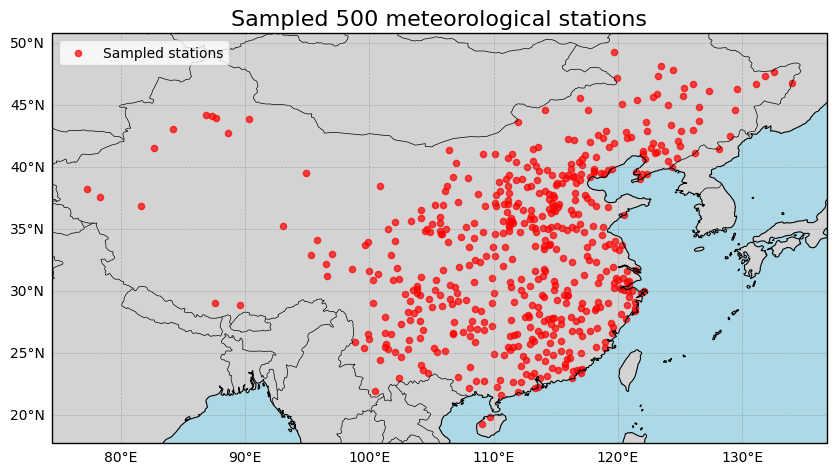

In [23]:
# ===== Plot sampled station map =====

# %pip install cartopy
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lons = coords_sample[:, 0]
lats = coords_sample[:, 1]

# Print sampled station information
print(f"Total sampled stations: {len(coords_sample)}")
print("\nSampled station coordinates (longitude, latitude):")
print(f"{'Index':<8} {'Longitude':<15} {'Latitude':<15}")
print("-" * 38)
for i, (lon, lat) in enumerate(coords_sample):
    print(f"{i:<8} {lon:<15.4f} {lat:<15.4f}")

# Plot map
plt.figure(figsize=(10, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# Add gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"fontsize": 10}
gl.ylabel_style = {"fontsize": 10}

# Plot sampled points
ax.scatter(
    lons,
    lats,
    color="red",
    s=20,
    transform=ccrs.PlateCarree(),
    alpha=0.7,
    label="Sampled stations"
)

plt.title(f"Sampled {n_sample} meteorological stations", fontsize=16)
plt.legend(
    loc="upper left",
    fontsize=10,
    frameon=True,
    facecolor="white",
    framealpha=0.8
)
plt.show()

### Training 500

### DLinear

#### tune par (optuna)

In [24]:
# import json
# import time
# import gc
# import os
# import logging
# import contextlib
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import optuna

# from darts import TimeSeries
# from darts.models import DLinearModel
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# print("\n===== DLinear hyperparameter search with Optuna (train/val/test = 70/15/15) =====")

# optuna.logging.set_verbosity(optuna.logging.WARNING)
# logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

# # Global settings & search controls
# RUN_SEARCH = False  # 是否執行搜尋；如果 False，會嘗試從 BEST_RESULT_PATH 載入結果並顯示（如果檔案存在的話）
# N_TRIALS = 500
# TIMEOUT_SECONDS = None

# USE_COVARIATES = False
# USE_REVIN = True
# RANDOM_STATE = 42

# PL_TRAINER_KWARGS = {
#     "enable_progress_bar": False,
#     "logger": False,
#     "enable_checkpointing": False,
#     "enable_model_summary": False,
# }

# SAVE_DIR = Path(".")
# BEST_RESULT_PATH = SAVE_DIR / "best_dlinear_result.json"
# BEST_PARAMS_PATH = SAVE_DIR / "best_dlinear_params.json"


# def _json_dump(obj, path: Path) -> None:
#     path.parent.mkdir(parents=True, exist_ok=True)
#     with open(path, "w", encoding="utf-8") as f:
#         json.dump(obj, f, ensure_ascii=False, indent=2)


# def _json_load(path: Path):
#     with open(path, "r", encoding="utf-8") as f:
#         return json.load(f)


# def _cleanup_torch_cache() -> None:
#     try:
#         import torch
#         if torch.cuda.is_available():
#             torch.cuda.empty_cache()
#     except Exception:
#         pass


# def _ts_to_2d(ts: TimeSeries) -> np.ndarray:
#     arr = np.asarray(ts.all_values(copy=False))
#     if arr.ndim == 3:
#         arr = arr[..., 0]
#     return arr


# def _build_model_kwargs(
#     in_len: int,
#     out_len: int,
#     ksize: int,
#     n_epochs: int,
#     bs: int,
#     lr: float,
#     wd: float,
#     const_init: bool,
# ) -> dict:
#     return {
#         "input_chunk_length": int(in_len),
#         "output_chunk_length": int(out_len),
#         "kernel_size": int(ksize),
#         "n_epochs": int(n_epochs),
#         "random_state": int(RANDOM_STATE),
#         "use_reversible_instance_norm": bool(USE_REVIN),
#         "batch_size": int(bs),
#         "optimizer_kwargs": {
#             "lr": float(lr),
#             "weight_decay": float(wd),
#         },
#         "const_init": bool(const_init),
#         "pl_trainer_kwargs": PL_TRAINER_KWARGS,
#         "log_tensorboard": False,
#         "save_checkpoints": False,
#     }


# def _compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
#     mse = mean_squared_error(y_true, y_pred)
#     mae = mean_absolute_error(y_true, y_pred)
#     rmse = float(np.sqrt(mse))
#     r2 = r2_score(y_true, y_pred)
#     return {
#         "rmse": float(rmse),
#         "mse": float(mse),
#         "mae": float(mae),
#         "r2": float(r2),
#     }


# def _silent_call(func, *args, **kwargs):
#     with open(os.devnull, "w") as fnull:
#         with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
#             return func(*args, **kwargs)


# SAMPLE_SIZE = int(n_sample)
# T = int(y_sample.shape[1])

# if y_sample.ndim != 2:
#     raise ValueError(f"y_sample 必須是 2 維陣列，目前 shape = {y_sample.shape}")

# if y_sample.shape[0] != SAMPLE_SIZE:
#     raise ValueError(
#         f"n_sample = {SAMPLE_SIZE}，但 y_sample.shape[0] = {y_sample.shape[0]}，兩者不一致"
#     )

# if len(time_index) != T:
#     raise ValueError(
#         f"time_index 長度 = {len(time_index)}，但 y_sample.shape[1] = {T}，兩者不一致"
#     )

# ts_df = pd.DataFrame(
#     y_sample.T,
#     index=time_index,
#     columns=[f"cell_{i}" for i in range(SAMPLE_SIZE)]
# ).astype("float32")

# print("Total time steps:", T)
# print("SAMPLE_SIZE:", SAMPLE_SIZE)
# print("ts_df shape:", ts_df.shape)

# month_values = time_index.month.astype("float32")
# month_df = pd.DataFrame({"month": month_values}, index=time_index)
# month_ts = TimeSeries.from_dataframe(month_df.astype("float32"))

# train_frac = 0.7
# val_frac = 0.15
# test_frac = 0.15

# if not np.isclose(train_frac + val_frac + test_frac, 1.0):
#     raise ValueError("train_frac + val_frac + test_frac 必須等於 1")

# cut_train = int(T * train_frac)
# cut_val = int(T * (train_frac + val_frac))

# idx = ts_df.index
# split_time_train = idx[cut_train]
# split_time_val = idx[cut_val]

# ts_all_raw = TimeSeries.from_dataframe(ts_df)
# trainval_raw, test_raw = ts_all_raw.split_before(split_time_val)
# train_raw, val_raw = trainval_raw.split_before(split_time_train)

# print(f"Train len (raw): {len(train_raw)}, Val len: {len(val_raw)}, Test len: {len(test_raw)}")

# month_trainval, month_test = month_ts.split_before(split_time_val)
# month_train, month_val = month_trainval.split_before(split_time_train)

# assert len(month_train) == len(train_raw)
# assert len(month_val) == len(val_raw)
# assert len(month_test) == len(test_raw)

# train_df = ts_df.iloc[:cut_train]
# mean_vec = train_df.mean(axis=0)
# std_vec = train_df.std(axis=0).replace(0.0, 1.0)

# ts_df_scaled = (ts_df - mean_vec) / std_vec
# ts_all_scaled = TimeSeries.from_dataframe(ts_df_scaled)

# trainval_ts, test_ts = ts_all_scaled.split_before(split_time_val)
# train_ts, val_ts = trainval_ts.split_before(split_time_train)

# T_train, T_val, T_test = len(train_ts), len(val_ts), len(test_ts)
# print("\n[Scaled lengths] T_train =", T_train, "T_val =", T_val, "T_test =", T_test)

# val_true_raw = ts_df.to_numpy(dtype=np.float32)[cut_train:cut_val, :]
# test_true_raw = ts_df.to_numpy(dtype=np.float32)[cut_val:, :]


# def inverse_scale(x: np.ndarray) -> np.ndarray:
#     return x * std_vec.values + mean_vec.values


# SEARCH_SPACE = {
#     "INPUT_CHUNK_LENGTH": [24, 36, 48],
#     "OUTPUT_CHUNK_LENGTH": [12, 24],
#     "KERNEL_SIZE": [15, 25],
#     "N_EPOCHS": [30, 50],
#     "BATCH_SIZE": [16, 32, 64],
#     "LR": [1e-4, 2e-4, 3e-4],
#     "WEIGHT_DECAY": [0.0, 1e-5],
#     "CONST_INIT": [True, False],
# }

# keys = list(SEARCH_SPACE.keys())

# if (not RUN_SEARCH) and BEST_RESULT_PATH.exists():
#     best_loaded = _json_load(BEST_RESULT_PATH)

#     print("\n===== LOADED BEST RESULT (skip search) =====")
#     print("Best VAL metrics:")
#     print(f"  RMSE = {best_loaded['rmse_val']:.6f}")
#     print(f"  MSE  = {best_loaded['mse_val']:.6f}")
#     print(f"  MAE  = {best_loaded['mae_val']:.6f}")
#     print(f"  R2   = {best_loaded['r2_val']:.6f}")

#     print("\nBest TEST metrics:")
#     print(f"  RMSE = {best_loaded['rmse_test']:.6f}")
#     print(f"  MSE  = {best_loaded['mse_test']:.6f}")
#     print(f"  MAE  = {best_loaded['mae_test']:.6f}")
#     print(f"  R2   = {best_loaded['r2_test']:.6f}")

#     print("\nBest params:")
#     for k in keys:
#         print(f"  {k} = {best_loaded['params'][k]}")
#     print(f"  USE_REVIN = {best_loaded['params']['USE_REVIN']}")
#     print(f"  USE_COVARIATES = {best_loaded['params']['USE_COVARIATES']}")
#     print(f"  RANDOM_STATE = {best_loaded['params']['RANDOM_STATE']}")
# else:
#     def objective(trial: optuna.Trial) -> float:
#         print(f"[Trial {trial.number + 1}/{N_TRIALS}]", flush=True)

#         in_len = trial.suggest_categorical(
#             "INPUT_CHUNK_LENGTH",
#             SEARCH_SPACE["INPUT_CHUNK_LENGTH"]
#         )
#         out_len = trial.suggest_categorical(
#             "OUTPUT_CHUNK_LENGTH",
#             SEARCH_SPACE["OUTPUT_CHUNK_LENGTH"]
#         )
#         ksize = trial.suggest_categorical(
#             "KERNEL_SIZE",
#             SEARCH_SPACE["KERNEL_SIZE"]
#         )
#         n_epochs = trial.suggest_categorical(
#             "N_EPOCHS",
#             SEARCH_SPACE["N_EPOCHS"]
#         )
#         bs = trial.suggest_categorical(
#             "BATCH_SIZE",
#             SEARCH_SPACE["BATCH_SIZE"]
#         )
#         lr = trial.suggest_categorical(
#             "LR",
#             SEARCH_SPACE["LR"]
#         )
#         wd = trial.suggest_categorical(
#             "WEIGHT_DECAY",
#             SEARCH_SPACE["WEIGHT_DECAY"]
#         )
#         const_init = trial.suggest_categorical(
#             "CONST_INIT",
#             SEARCH_SPACE["CONST_INIT"]
#         )

#         model_kwargs = _build_model_kwargs(
#             in_len=in_len,
#             out_len=out_len,
#             ksize=ksize,
#             n_epochs=n_epochs,
#             bs=bs,
#             lr=lr,
#             wd=wd,
#             const_init=const_init,
#         )

#         model = None
#         pred_val = None

#         fit_kwargs = {
#             "series": train_ts,
#             "verbose": False,
#         }
#         pred_val_kwargs = {
#             "n": T_val,
#             "verbose": False,
#             "show_warnings": False,
#         }

#         if USE_COVARIATES:
#             fit_kwargs["past_covariates"] = month_train
#             fit_kwargs["future_covariates"] = month_train
#             pred_val_kwargs["past_covariates"] = month_trainval
#             pred_val_kwargs["future_covariates"] = month_trainval

#         try:
#             model = DLinearModel(**model_kwargs)
#             _silent_call(model.fit, **fit_kwargs)
#             pred_val = _silent_call(model.predict, **pred_val_kwargs)

#             pred_val_scaled = _ts_to_2d(pred_val)
#             pred_val_raw = inverse_scale(pred_val_scaled)

#             y_val_true = val_true_raw.reshape(-1, SAMPLE_SIZE)
#             y_val_pred = pred_val_raw.reshape(-1, SAMPLE_SIZE)

#             val_metrics = _compute_metrics(y_val_true, y_val_pred)

#             trial.set_user_attr("rmse_val", val_metrics["rmse"])
#             trial.set_user_attr("mse_val", val_metrics["mse"])
#             trial.set_user_attr("mae_val", val_metrics["mae"])
#             trial.set_user_attr("r2_val", val_metrics["r2"])
#             trial.set_user_attr("USE_REVIN", bool(USE_REVIN))
#             trial.set_user_attr("USE_COVARIATES", bool(USE_COVARIATES))
#             trial.set_user_attr("RANDOM_STATE", int(RANDOM_STATE))

#             return trial.user_attrs["rmse_val"]

#         except Exception:
#             raise optuna.TrialPruned()

#         finally:
#             del model
#             del pred_val
#             gc.collect()
#             _cleanup_torch_cache()

#     study = optuna.create_study(
#         direction="minimize",
#         sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
#         pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=0),
#     )

#     study.optimize(
#         objective,
#         n_trials=N_TRIALS,
#         timeout=TIMEOUT_SECONDS,
#         gc_after_trial=True,
#         show_progress_bar=False,
#     )

#     print("\n===== BEST PARAMS (by VAL RMSE) =====")

#     successful_trials = [
#         t for t in study.trials
#         if t.state == optuna.trial.TrialState.COMPLETE
#     ]

#     print(f"Successful trials: {len(successful_trials)} / {len(study.trials)}")

#     if len(successful_trials) == 0:
#         print("No successful run in the search space.")
#     else:
#         best_trial = study.best_trial

#         best_params = {
#             "INPUT_CHUNK_LENGTH": best_trial.params["INPUT_CHUNK_LENGTH"],
#             "OUTPUT_CHUNK_LENGTH": best_trial.params["OUTPUT_CHUNK_LENGTH"],
#             "KERNEL_SIZE": best_trial.params["KERNEL_SIZE"],
#             "N_EPOCHS": best_trial.params["N_EPOCHS"],
#             "BATCH_SIZE": best_trial.params["BATCH_SIZE"],
#             "LR": float(best_trial.params["LR"]),
#             "WEIGHT_DECAY": float(best_trial.params["WEIGHT_DECAY"]),
#             "CONST_INIT": bool(best_trial.params["CONST_INIT"]),
#             "USE_REVIN": bool(USE_REVIN),
#             "USE_COVARIATES": bool(USE_COVARIATES),
#             "RANDOM_STATE": int(RANDOM_STATE),
#         }

#         print("Best VAL metrics:")
#         print(f"  RMSE = {best_trial.user_attrs['rmse_val']:.6f}")
#         print(f"  MSE  = {best_trial.user_attrs['mse_val']:.6f}")
#         print(f"  MAE  = {best_trial.user_attrs['mae_val']:.6f}")
#         print(f"  R2   = {best_trial.user_attrs['r2_val']:.6f}")

#         best_model_kwargs = _build_model_kwargs(
#             in_len=best_params["INPUT_CHUNK_LENGTH"],
#             out_len=best_params["OUTPUT_CHUNK_LENGTH"],
#             ksize=best_params["KERNEL_SIZE"],
#             n_epochs=best_params["N_EPOCHS"],
#             bs=best_params["BATCH_SIZE"],
#             lr=best_params["LR"],
#             wd=best_params["WEIGHT_DECAY"],
#             const_init=best_params["CONST_INIT"],
#         )

#         best_model = DLinearModel(**best_model_kwargs)

#         fit_best_kwargs = {
#             "series": trainval_ts,
#             "verbose": False,
#         }
#         pred_test_kwargs = {
#             "n": T_test,
#             "verbose": False,
#             "show_warnings": False,
#         }

#         if USE_COVARIATES:
#             fit_best_kwargs["past_covariates"] = month_trainval
#             fit_best_kwargs["future_covariates"] = month_trainval
#             pred_test_kwargs["past_covariates"] = month_ts
#             pred_test_kwargs["future_covariates"] = month_ts

#         _silent_call(best_model.fit, **fit_best_kwargs)
#         pred_test = _silent_call(best_model.predict, **pred_test_kwargs)

#         pred_test_scaled = _ts_to_2d(pred_test)
#         pred_test_raw = inverse_scale(pred_test_scaled)

#         y_test_true = test_true_raw.reshape(-1, SAMPLE_SIZE)
#         y_test_pred = pred_test_raw.reshape(-1, SAMPLE_SIZE)

#         test_metrics = _compute_metrics(y_test_true, y_test_pred)

#         best_result_payload = {
#             "rmse_val": float(best_trial.user_attrs["rmse_val"]),
#             "mse_val": float(best_trial.user_attrs["mse_val"]),
#             "mae_val": float(best_trial.user_attrs["mae_val"]),
#             "r2_val": float(best_trial.user_attrs["r2_val"]),
#             "rmse_test": float(test_metrics["rmse"]),
#             "mse_test": float(test_metrics["mse"]),
#             "mae_test": float(test_metrics["mae"]),
#             "r2_test": float(test_metrics["r2"]),
#             "params": best_params,
#             "search_space": SEARCH_SPACE,
#             "n_trials": int(N_TRIALS),
#             "best_trial_number": int(best_trial.number),
#             "successful_trials": int(len(successful_trials)),
#             "split_ratio": {
#                 "train": train_frac,
#                 "val": val_frac,
#                 "test": test_frac,
#             },
#             "sample_size": int(SAMPLE_SIZE),
#             "time_steps": int(T),
#         }

#         print("\nBest TEST metrics:")
#         print(f"  RMSE = {best_result_payload['rmse_test']:.6f}")
#         print(f"  MSE  = {best_result_payload['mse_test']:.6f}")
#         print(f"  MAE  = {best_result_payload['mae_test']:.6f}")
#         print(f"  R2   = {best_result_payload['r2_test']:.6f}")

#         print("\nBest params:")
#         for k in keys:
#             print(f"  {k} = {best_params[k]}")
#         print(f"  USE_REVIN = {best_params['USE_REVIN']}")
#         print(f"  USE_COVARIATES = {best_params['USE_COVARIATES']}")
#         print(f"  RANDOM_STATE = {best_params['RANDOM_STATE']}")
#         print(f"  BEST_TRIAL_NUMBER = {best_trial.number}")

#         _json_dump(best_result_payload, BEST_RESULT_PATH)
#         _json_dump(best_params, BEST_PARAMS_PATH)

#         print("\nSaved:")
#         print(f"  - {BEST_RESULT_PATH.resolve()}")
#         print(f"  - {BEST_PARAMS_PATH.resolve()}")

#         del best_model
#         del pred_test, pred_test_scaled, pred_test_raw
#         del y_test_true, y_test_pred, test_metrics
#         gc.collect()
#         _cleanup_torch_cache()

#### rerun best par

In [25]:
# # ============================================================
# # 8) Re-run DLinear with BEST params (train+val -> test)
# #    Priority:
# #      (1) load from best_dlinear_params.json
# #      (2) fallback: load params from best_dlinear_result.json
# # ============================================================
# from pathlib import Path
# import json
# import gc
# import numpy as np
# import pandas as pd
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from darts.models import DLinearModel

# BEST_PARAMS_PATH = Path("best_dlinear_params.json")
# BEST_RESULT_PATH = Path("best_dlinear_result.json")
# RERUN_METRICS_PATH = Path("best_dlinear_rerun_metrics.json")


# def _json_load(path: Path):
#     with open(path, "r", encoding="utf-8") as f:
#         return json.load(f)


# def _json_dump(obj, path: Path) -> None:
#     path.parent.mkdir(parents=True, exist_ok=True)
#     with open(path, "w", encoding="utf-8") as f:
#         json.dump(obj, f, ensure_ascii=False, indent=2)


# def _cleanup_torch_cache() -> None:
#     try:
#         import torch
#         if torch.cuda.is_available():
#             torch.cuda.empty_cache()
#     except Exception:
#         pass


# bp = None

# if BEST_PARAMS_PATH.exists():
#     bp = _json_load(BEST_PARAMS_PATH)
# elif BEST_RESULT_PATH.exists():
#     best_result_loaded = _json_load(BEST_RESULT_PATH)
#     bp = best_result_loaded.get("params", None)

# if bp is None:
#     raise RuntimeError(
#         "No best params found. Please make sure best_dlinear_params.json "
#         "or best_dlinear_result.json exists."
#     )

# print("\n===== RE-RUN DLinear with BEST params (train+val/test = 85/15 under 70/15/15 split) =====")
# print("Best params used:")
# for k in keys:
#     if k in bp:
#         print(f"  {k} = {bp[k]}")
# print(f"  USE_REVIN = {bp.get('USE_REVIN', USE_REVIN)}")
# print(f"  USE_COVARIATES = {bp.get('USE_COVARIATES', USE_COVARIATES)}")
# print(f"  RANDOM_STATE = {bp.get('RANDOM_STATE', RANDOM_STATE)}")

# model_best_kwargs = dict(
#     input_chunk_length=int(bp["INPUT_CHUNK_LENGTH"]),
#     output_chunk_length=int(bp["OUTPUT_CHUNK_LENGTH"]),
#     kernel_size=int(bp["KERNEL_SIZE"]),
#     n_epochs=int(bp["N_EPOCHS"]),
#     random_state=int(bp.get("RANDOM_STATE", RANDOM_STATE)),
#     use_reversible_instance_norm=bool(bp.get("USE_REVIN", USE_REVIN)),
#     batch_size=int(bp["BATCH_SIZE"]),
#     optimizer_kwargs={
#         "lr": float(bp["LR"]),
#         "weight_decay": float(bp["WEIGHT_DECAY"]),
#     },
#     const_init=bool(bp["CONST_INIT"]),
#     pl_trainer_kwargs=PL_TRAINER_KWARGS,
#     log_tensorboard=False,
#     save_checkpoints=False,
# )

# model_best = DLinearModel(**model_best_kwargs)

# fit_kwargs_best = {
#     "series": trainval_ts,
#     "verbose": False,
# }
# pred_kwargs_best = {
#     "n": T_test,
#     "verbose": False,
#     "show_warnings": False,
# }

# if bool(bp.get("USE_COVARIATES", USE_COVARIATES)):
#     fit_kwargs_best["past_covariates"] = month_trainval
#     fit_kwargs_best["future_covariates"] = month_trainval
#     pred_kwargs_best["past_covariates"] = month_ts
#     pred_kwargs_best["future_covariates"] = month_ts

# model_best.fit(**fit_kwargs_best)
# pred_best = model_best.predict(**pred_kwargs_best)

# pred_best_scaled = _ts_to_2d(pred_best)
# pred_best_raw = inverse_scale(pred_best_scaled)

# y_test_true_best = test_true_raw.reshape(-1, SAMPLE_SIZE)
# y_test_pred_best = pred_best_raw.reshape(-1, SAMPLE_SIZE)

# mse_best = mean_squared_error(y_test_true_best, y_test_pred_best)
# mae_best = mean_absolute_error(y_test_true_best, y_test_pred_best)
# rmse_best = float(np.sqrt(mse_best))
# r2_best = r2_score(y_test_true_best, y_test_pred_best)

# metrics_best = pd.DataFrame({
#     "Model": ["DLINEAR(best)"],
#     "Split": ["TEST"],
#     "RMSE": [rmse_best],
#     "MSE": [float(mse_best)],
#     "MAE": [float(mae_best)],
#     "R2": [float(r2_best)],
# })

# print("\n===== BEST DLINEAR RESULTS (re-run) =====")
# print(metrics_best.to_string(index=False))

# rerun_payload = {
#     "Model": "DLINEAR(best)",
#     "Split": "TEST",
#     "RMSE": float(rmse_best),
#     "MSE": float(mse_best),
#     "MAE": float(mae_best),
#     "R2": float(r2_best),
#     "params_used": bp,
#     "train_series_used": "trainval_ts",
#     "test_series_used": "test_ts",
#     "split_ratio": {
#         "train": 0.7,
#         "val": 0.15,
#         "test": 0.15,
#     },
# }

# _json_dump(rerun_payload, RERUN_METRICS_PATH)
# print(f"\nSaved re-run metrics: {RERUN_METRICS_PATH.resolve()}")

# del model_best, pred_best, pred_best_scaled, pred_best_raw
# del y_test_true_best, y_test_pred_best, mse_best, mae_best, rmse_best, r2_best
# gc.collect()
# _cleanup_torch_cache()

### autoFRK

In [26]:
# # ============================================================
# # 9) DLinear + autoFRK rolling residual forecast
# #    Use DLinear(best, trained on train+val) residuals -> autoFRK -> test rolling forecast
# # ============================================================
# import gc
# import json
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import torch
# from autoFRK import AutoFRK
# from darts.models import DLinearModel
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# print("\n===== DLinear + autoFRK rolling residual forecast =====")

# BEST_PARAMS_PATH = Path("best_dlinear_params.json")
# BEST_RESULT_PATH = Path("best_dlinear_result.json")
# FRK_METRICS_PATH = Path("dlinear_autofrk_rolling_test_metrics.json")


# def _json_load(path: Path):
#     with open(path, "r", encoding="utf-8") as f:
#         return json.load(f)


# def _cleanup_torch_cache() -> None:
#     try:
#         import torch as _torch
#         if _torch.cuda.is_available():
#             _torch.cuda.empty_cache()
#     except Exception:
#         pass


# def _ts_to_2d(ts):
#     arr = np.asarray(ts.all_values(copy=False))
#     if arr.ndim == 3:
#         arr = arr[..., 0]
#     return arr.astype(np.float64, copy=False)


# def inverse_scale_2d(x_TN):
#     return x_TN * std_arr[None, :] + mean_arr[None, :]


# # ------------------------------------------------------------
# # 0) Load best params
# # ------------------------------------------------------------
# bp = None
# if BEST_PARAMS_PATH.exists():
#     bp = _json_load(BEST_PARAMS_PATH)
# elif BEST_RESULT_PATH.exists():
#     bp = _json_load(BEST_RESULT_PATH).get("params", None)

# if bp is None:
#     raise RuntimeError(
#         "No best params found. Please make sure best_dlinear_params.json "
#         "or best_dlinear_result.json exists."
#     )

# # ------------------------------------------------------------
# # 1) Rebuild / reuse best DLinear model on train+val -> test
# # ------------------------------------------------------------
# need_refit_best_model = (
#     ("model_best" not in globals()) or
#     ("pred_best_raw" not in globals())
# )

# if need_refit_best_model:
#     print("model_best / pred_best_raw not found in memory. Re-fitting best DLinear on train+val...")

#     model_best_kwargs = dict(
#         input_chunk_length=int(bp["INPUT_CHUNK_LENGTH"]),
#         output_chunk_length=int(bp["OUTPUT_CHUNK_LENGTH"]),
#         kernel_size=int(bp["KERNEL_SIZE"]),
#         n_epochs=int(bp["N_EPOCHS"]),
#         random_state=int(bp.get("RANDOM_STATE", RANDOM_STATE)),
#         use_reversible_instance_norm=bool(bp.get("USE_REVIN", USE_REVIN)),
#         batch_size=int(bp["BATCH_SIZE"]),
#         optimizer_kwargs={
#             "lr": float(bp["LR"]),
#             "weight_decay": float(bp["WEIGHT_DECAY"]),
#         },
#         const_init=bool(bp["CONST_INIT"]),
#         pl_trainer_kwargs=PL_TRAINER_KWARGS,
#         log_tensorboard=False,
#         save_checkpoints=False,
#     )

#     model_best = DLinearModel(**model_best_kwargs)

#     fit_kwargs_best = {
#         "series": trainval_ts,
#         "verbose": False,
#     }
#     pred_kwargs_best = {
#         "n": T_test,
#         "verbose": False,
#         "show_warnings": False,
#     }

#     if bool(bp.get("USE_COVARIATES", USE_COVARIATES)):
#         fit_kwargs_best["past_covariates"] = month_trainval
#         fit_kwargs_best["future_covariates"] = month_trainval
#         pred_kwargs_best["past_covariates"] = month_ts
#         pred_kwargs_best["future_covariates"] = month_ts

#     model_best.fit(**fit_kwargs_best)
#     pred_best = model_best.predict(**pred_kwargs_best)

#     pred_best_scaled = _ts_to_2d(pred_best)
#     pred_best_raw = inverse_scale(pred_best_scaled)

#     del pred_best, pred_best_scaled
#     gc.collect()
#     _cleanup_torch_cache()

# # ------------------------------------------------------------
# # 2) Basic objects
# # ------------------------------------------------------------
# coords = coords_sample.astype(np.float64)
# loc = torch.from_numpy(coords).to(dtype=torch.float64, device="cpu")

# N = coords.shape[0]
# H = T_test

# mean_arr = mean_vec.values.astype(np.float64)
# std_arr = std_vec.values.astype(np.float64)

# if mean_arr.shape[0] != N:
#     raise ValueError(f"mean_vec 長度 {mean_arr.shape[0]} 與格點數 N={N} 不一致")
# if std_arr.shape[0] != N:
#     raise ValueError(f"std_vec 長度 {std_arr.shape[0]} 與格點數 N={N} 不一致")
# if ts_df.shape[1] != N:
#     raise ValueError(f"ts_df 欄數 {ts_df.shape[1]} 與格點數 N={N} 不一致")

# input_chunk_length_best = int(bp["INPUT_CHUNK_LENGTH"])

# # ------------------------------------------------------------
# # 3) Build residual history from train+val period
# # ------------------------------------------------------------
# y_hist_raw_TN = ts_df.iloc[:cut_val, :].to_numpy(dtype=np.float64)
# hist_index = ts_df.index[:cut_val]
# T_hist = y_hist_raw_TN.shape[0]

# hist_forecast_kwargs = {
#     "series": trainval_ts,
#     "start": input_chunk_length_best,
#     "forecast_horizon": 1,
#     "stride": 1,
#     "retrain": False,
#     "last_points_only": True,
#     "verbose": False,
# }

# if bool(bp.get("USE_COVARIATES", USE_COVARIATES)):
#     hist_forecast_kwargs["past_covariates"] = month_trainval
#     hist_forecast_kwargs["future_covariates"] = month_trainval

# pred_hist = model_best.historical_forecasts(**hist_forecast_kwargs)

# if isinstance(pred_hist, list):
#     if len(pred_hist) == 0:
#         raise RuntimeError("historical_forecasts 回傳空 list，無法建立 residual history。")
#     pred_hist_ts = pred_hist[0]
#     for k in range(1, len(pred_hist)):
#         pred_hist_ts = pred_hist_ts.append(pred_hist[k])
# else:
#     pred_hist_ts = pred_hist

# pred_hist_scaled_TN = _ts_to_2d(pred_hist_ts)
# pred_time_index = pred_hist_ts.time_index

# trend_hat_hist_raw_TN = np.full((T_hist, N), np.nan, dtype=np.float64)

# pos = hist_index.get_indexer(pred_time_index)
# valid = pos >= 0
# pred_hist_scaled_TN = pred_hist_scaled_TN[valid]
# pos = pos[valid]

# pred_hist_raw_TN = inverse_scale_2d(pred_hist_scaled_TN)
# trend_hat_hist_raw_TN[pos] = pred_hist_raw_TN

# R_hist_raw_TN = y_hist_raw_TN - trend_hat_hist_raw_TN
# R_hist_raw_NT = R_hist_raw_TN.T

# nan_ratio = float(np.isnan(R_hist_raw_NT).mean())
# print("Residual history shape:", R_hist_raw_NT.shape, "| NaN ratio:", nan_ratio)

# valid_cols = ~np.isnan(R_hist_raw_NT).any(axis=0)
# R_hist_valid_NT = R_hist_raw_NT[:, valid_cols]

# if R_hist_valid_NT.shape[1] < 2:
#     raise RuntimeError("有效 residual 歷史長度不足，無法做 rolling latent forecast。")

# # ------------------------------------------------------------
# # 4) DLinear test trend
# # ------------------------------------------------------------
# trend_test_raw = pred_best_raw.astype(np.float64)
# if trend_test_raw.shape != (H, N):
#     raise ValueError(f"pred_best_raw shape {trend_test_raw.shape} 應為 {(H, N)}")

# y_test_true_combo = test_true_raw.reshape(H, N).astype(np.float64)

# # ------------------------------------------------------------
# # 5) Rolling residual forecast with autoFRK
# # ------------------------------------------------------------
# afrk = AutoFRK(dtype=torch.float64, device="cpu")

# Rhat_roll_NH = np.zeros((N, H), dtype=np.float64)
# K_list = []

# R_hist_roll_NT = R_hist_valid_NT.copy()

# for h in range(H):
#     data_hist = torch.from_numpy(R_hist_roll_NT).to(dtype=torch.float64)

#     result_h = afrk.forward(
#         data=data_hist,
#         loc=loc,
#         method="EM",
#         maxit=50,
#         tolerance=1e-6,
#         n_neighbor=3,
#         tps_method="spherical_fast",
#     )

#     w_hist = result_h["w"]
#     w_hist_np = w_hist.detach().cpu().numpy()
#     K, T_latent = w_hist_np.shape
#     K_list.append(int(K))

#     if T_latent < 2:
#         raise RuntimeError(f"第 {h+1} 步 latent 歷史長度不足，無法建立 VAR(1)。")

#     W0 = w_hist_np[:, :-1]
#     W1 = w_hist_np[:, 1:]
#     A = (W1 @ W0.T) @ np.linalg.pinv(W0 @ W0.T)

#     w_last = w_hist_np[:, -1]
#     w_next = (A @ w_last).reshape(K, 1)

#     obj_next = dict(result_h)
#     obj_next["w"] = torch.from_numpy(w_next).to(dtype=torch.float64)

#     pred_res_h = afrk.predict(
#         obj=obj_next,
#         newloc=loc,
#         se_report=False,
#         tps_method="spherical_fast",
#     )

#     rhat_h = pred_res_h["pred.value"].detach().cpu().numpy()

#     if rhat_h.ndim == 2 and rhat_h.shape == (N, 1):
#         rhat_h = rhat_h[:, 0]
#     elif rhat_h.ndim == 1 and rhat_h.shape[0] == N:
#         pass
#     else:
#         raise ValueError(f"第 {h+1} 步 residual prediction shape 異常: {rhat_h.shape}")

#     Rhat_roll_NH[:, h] = rhat_h

#     # 用真實 test residual 更新歷史，做 rolling one-step-ahead
#     y_true_h = y_test_true_combo[h, :]
#     trend_h = trend_test_raw[h, :]
#     r_true_h = y_true_h - trend_h

#     R_hist_roll_NT = np.column_stack([R_hist_roll_NT, r_true_h])

# # ------------------------------------------------------------
# # 6) Final combined forecast
# # ------------------------------------------------------------
# Yhat_test_combo = trend_test_raw + Rhat_roll_NH.T

# mse_combo = mean_squared_error(y_test_true_combo, Yhat_test_combo)
# mae_combo = mean_absolute_error(y_test_true_combo, Yhat_test_combo)
# rmse_combo = float(np.sqrt(mse_combo))
# r2_combo = r2_score(y_test_true_combo, Yhat_test_combo)

# mse_dlinear = mean_squared_error(y_test_true_combo, trend_test_raw)
# mae_dlinear = mean_absolute_error(y_test_true_combo, trend_test_raw)
# rmse_dlinear = float(np.sqrt(mse_dlinear))
# r2_dlinear = r2_score(y_test_true_combo, trend_test_raw)

# metrics_compare = pd.DataFrame({
#     "Model": ["DLinear(best)", "DLinear + autoFRK rolling"],
#     "Split": ["TEST", "TEST"],
#     "RMSE": [rmse_dlinear, rmse_combo],
#     "MSE": [float(mse_dlinear), float(mse_combo)],
#     "MAE": [float(mae_dlinear), float(mae_combo)],
#     "R2": [float(r2_dlinear), float(r2_combo)],
# })

# print("\n===== DLinear vs DLinear + autoFRK rolling =====")
# print(metrics_compare.to_string(index=False))

# frk_payload = {
#     "dlinear_best": {
#         "RMSE": float(rmse_dlinear),
#         "MSE": float(mse_dlinear),
#         "MAE": float(mae_dlinear),
#         "R2": float(r2_dlinear),
#     },
#     "dlinear_autofrk_rolling": {
#         "RMSE": float(rmse_combo),
#         "MSE": float(mse_combo),
#         "MAE": float(mae_combo),
#         "R2": float(r2_combo),
#     },
#     "N": int(N),
#     "H": int(H),
#     "K_first_step": int(K_list[0]) if len(K_list) > 0 else None,
#     "K_last_step": int(K_list[-1]) if len(K_list) > 0 else None,
#     "residual_history_nan_ratio": float(nan_ratio),
#     "residual_history_length_used": int(R_hist_valid_NT.shape[1]),
#     "params_used": bp,
#     "split_ratio": {
#         "train": 0.7,
#         "val": 0.15,
#         "test": 0.15,
#     },
# }

# _json_dump(frk_payload, FRK_METRICS_PATH)
# print(f"\nSaved rolling FRK metrics: {FRK_METRICS_PATH.resolve()}")

#### Debug

In [27]:
# # ============================================================
# # 10) Debug diagnostics for DLinear residual + autoFRK rolling
# # ============================================================
# from pathlib import Path
# import json
# import numpy as np
# import pandas as pd

# DEBUG_METRICS_PATH = Path("dlinear_autofrk_debug_metrics.json")

# def _json_dump(obj, path: Path) -> None:
#     path.parent.mkdir(parents=True, exist_ok=True)
#     with open(path, "w", encoding="utf-8") as f:
#         json.dump(obj, f, ensure_ascii=False, indent=2)

# if "Rhat_roll_NH" not in globals():
#     raise RuntimeError("Rhat_roll_NH 不存在，請先完成第 9 段 rolling residual forecast。")
# if "trend_test_raw" not in globals():
#     raise RuntimeError("trend_test_raw 不存在，請先完成第 9 段。")
# if "y_test_true_combo" not in globals():
#     raise RuntimeError("y_test_true_combo 不存在，請先完成第 9 段。")
# if "R_hist_valid_NT" not in globals():
#     raise RuntimeError("R_hist_valid_NT 不存在，請先完成第 9 段。")
# if "coords" not in globals():
#     raise RuntimeError("coords 不存在，請先完成第 9 段。")

# r_true_test_TN = y_test_true_combo - trend_test_raw
# r_hat_test_TN = Rhat_roll_NH.T

# if r_true_test_TN.shape != r_hat_test_TN.shape:
#     raise ValueError(
#         f"r_true_test_TN.shape = {r_true_test_TN.shape}, "
#         f"r_hat_test_TN.shape = {r_hat_test_TN.shape}"
#     )

# H, N = r_true_test_TN.shape

# rmse_residual_zero_by_h = []
# rmse_residual_frk_by_h = []
# mae_residual_zero_by_h = []
# mae_residual_frk_by_h = []
# corr_residual_by_h = []
# sd_true_by_h = []
# sd_hat_by_h = []
# norm_ratio_by_h = []
# mean_true_by_h = []
# mean_hat_by_h = []

# for h in range(H):
#     r_true_h = r_true_test_TN[h, :]
#     r_hat_h = r_hat_test_TN[h, :]
#     r_zero_h = np.zeros_like(r_true_h)

#     rmse_zero = float(np.sqrt(np.mean((r_true_h - r_zero_h) ** 2)))
#     rmse_frk = float(np.sqrt(np.mean((r_true_h - r_hat_h) ** 2)))
#     mae_zero = float(np.mean(np.abs(r_true_h - r_zero_h)))
#     mae_frk = float(np.mean(np.abs(r_true_h - r_hat_h)))

#     if np.std(r_true_h) == 0 or np.std(r_hat_h) == 0:
#         corr_h = np.nan
#     else:
#         corr_h = float(np.corrcoef(r_true_h, r_hat_h)[0, 1])

#     sd_true = float(np.std(r_true_h))
#     sd_hat = float(np.std(r_hat_h))
#     nr = float(np.linalg.norm(r_hat_h) / (np.linalg.norm(r_true_h) + 1e-12))

#     rmse_residual_zero_by_h.append(rmse_zero)
#     rmse_residual_frk_by_h.append(rmse_frk)
#     mae_residual_zero_by_h.append(mae_zero)
#     mae_residual_frk_by_h.append(mae_frk)
#     corr_residual_by_h.append(corr_h)
#     sd_true_by_h.append(sd_true)
#     sd_hat_by_h.append(sd_hat)
#     norm_ratio_by_h.append(nr)
#     mean_true_by_h.append(float(np.mean(r_true_h)))
#     mean_hat_by_h.append(float(np.mean(r_hat_h)))

# residual_step_df = pd.DataFrame({
#     "h": np.arange(1, H + 1),
#     "rmse_zero": rmse_residual_zero_by_h,
#     "rmse_frk": rmse_residual_frk_by_h,
#     "rmse_gain": np.array(rmse_residual_zero_by_h) - np.array(rmse_residual_frk_by_h),
#     "mae_zero": mae_residual_zero_by_h,
#     "mae_frk": mae_residual_frk_by_h,
#     "mae_gain": np.array(mae_residual_zero_by_h) - np.array(mae_residual_frk_by_h),
#     "corr_true_hat": corr_residual_by_h,
#     "sd_true": sd_true_by_h,
#     "sd_hat": sd_hat_by_h,
#     "sd_ratio_hat_true": np.array(sd_hat_by_h) / (np.array(sd_true_by_h) + 1e-12),
#     "norm_ratio_hat_true": norm_ratio_by_h,
#     "mean_true": mean_true_by_h,
#     "mean_hat": mean_hat_by_h,
# })

# print("\n===== Residual-level diagnostics =====")
# print(residual_step_df.describe().to_string())

# n_rmse_better = int((residual_step_df["rmse_frk"] < residual_step_df["rmse_zero"]).sum())
# n_mae_better = int((residual_step_df["mae_frk"] < residual_step_df["mae_zero"]).sum())

# print(f"\nFRK residual better than zero baseline by RMSE in {n_rmse_better}/{H} steps")
# print(f"FRK residual better than zero baseline by MAE  in {n_mae_better}/{H} steps")

# # Spatial covariance diagnostics
# train_resid_NT = R_hist_valid_NT
# test_true_resid_NT = r_true_test_TN.T
# test_hat_resid_NT = r_hat_test_TN.T

# cov_train_resid = np.cov(train_resid_NT)
# cov_test_true_resid = np.cov(test_true_resid_NT)
# cov_test_hat_resid = np.cov(test_hat_resid_NT)

# fro_true_hat = float(
#     np.linalg.norm(cov_test_hat_resid - cov_test_true_resid, ord="fro")
#     / (np.linalg.norm(cov_test_true_resid, ord="fro") + 1e-12)
# )

# fro_train_true = float(
#     np.linalg.norm(cov_train_resid - cov_test_true_resid, ord="fro")
#     / (np.linalg.norm(cov_test_true_resid, ord="fro") + 1e-12)
# )

# fro_zero_true = 1.0

# print("\n===== Residual covariance diagnostics =====")
# print(f"CovFrob(test_hat_resid vs test_true_resid) = {fro_true_hat:.6f}")
# print(f"CovFrob(train_resid    vs test_true_resid) = {fro_train_true:.6f}")
# print(f"CovFrob(zero matrix    vs test_true_resid) = {fro_zero_true:.6f}")

# # Distance-binned correlation diagnostics
# dist_mat = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))
# iu = np.triu_indices(N, k=1)
# dist_vec = dist_mat[iu]

# corr_true = np.corrcoef(test_true_resid_NT)
# corr_hat = np.corrcoef(test_hat_resid_NT)

# corr_true_vec = corr_true[iu]
# corr_hat_vec = corr_hat[iu]

# n_bins = 10
# bins = np.quantile(dist_vec, np.linspace(0, 1, n_bins + 1))
# bins[0] = bins[0] - 1e-12
# bins[-1] = bins[-1] + 1e-12

# rows = []
# for b in range(n_bins):
#     mask = (dist_vec > bins[b]) & (dist_vec <= bins[b + 1])
#     if mask.sum() == 0:
#         continue
#     rows.append({
#         "bin": b + 1,
#         "n_pairs": int(mask.sum()),
#         "dist_left": float(bins[b]),
#         "dist_right": float(bins[b + 1]),
#         "mean_corr_true": float(np.nanmean(corr_true_vec[mask])),
#         "mean_corr_hat": float(np.nanmean(corr_hat_vec[mask])),
#         "abs_gap": float(np.abs(np.nanmean(corr_true_vec[mask]) - np.nanmean(corr_hat_vec[mask]))),
#     })

# dist_bin_df = pd.DataFrame(rows)

# print("\n===== Distance-binned residual correlation =====")
# print(dist_bin_df.to_string(index=False))

# debug_payload = {
#     "residual_step_summary": {
#         "rmse_zero_mean": float(np.nanmean(residual_step_df["rmse_zero"])),
#         "rmse_frk_mean": float(np.nanmean(residual_step_df["rmse_frk"])),
#         "rmse_gain_mean": float(np.nanmean(residual_step_df["rmse_gain"])),
#         "mae_zero_mean": float(np.nanmean(residual_step_df["mae_zero"])),
#         "mae_frk_mean": float(np.nanmean(residual_step_df["mae_frk"])),
#         "mae_gain_mean": float(np.nanmean(residual_step_df["mae_gain"])),
#         "corr_true_hat_mean": float(np.nanmean(residual_step_df["corr_true_hat"])),
#         "sd_ratio_hat_true_mean": float(np.nanmean(residual_step_df["sd_ratio_hat_true"])),
#         "norm_ratio_hat_true_mean": float(np.nanmean(residual_step_df["norm_ratio_hat_true"])),
#         "n_rmse_better_than_zero": int(n_rmse_better),
#         "n_mae_better_than_zero": int(n_mae_better),
#         "H": int(H),
#         "N": int(N),
#     },
#     "residual_covariance_summary": {
#         "covfrob_test_hat_vs_test_true": float(fro_true_hat),
#         "covfrob_train_vs_test_true": float(fro_train_true),
#         "covfrob_zero_vs_test_true": float(fro_zero_true),
#     },
#     "distance_binned_corr": rows,
# }

# _json_dump(debug_payload, DEBUG_METRICS_PATH)
# print(f"\nSaved debug metrics: {DEBUG_METRICS_PATH.resolve()}")

### Training 100, within 500

### DLinear

#### tune par (optuna)

In [28]:
import json
import time
import gc
import os
import logging
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import optuna

from darts import TimeSeries
from darts.models import DLinearModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


print("\n===== DLinear hyperparameter search (500 -> 100 sampling) =====")

optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

# Global settings & sampling control
RUN_SEARCH = True  # 是否執行超參數搜尋，若 False 則直接讀取 BEST_PARAMS_PATH 的參數重訓並評估
N_TRIALS = 500
TIMEOUT_SECONDS = None

USE_COVARIATES = False
USE_REVIN = True
RANDOM_STATE = 42

# sampling control
ORIGINAL_N = 500
TUNE_N = 100
SAMPLE_SEED = 123

PL_TRAINER_KWARGS = {
    "enable_progress_bar": False,
    "logger": False,
    "enable_checkpointing": False,
    "enable_model_summary": False,
}

SAVE_DIR = Path(".")
BEST_RESULT_PATH = SAVE_DIR / f"2K_best_dlinear_result_{ORIGINAL_N}to{TUNE_N}.json"
BEST_PARAMS_PATH = SAVE_DIR / f"2K_best_dlinear_params_{ORIGINAL_N}to{TUNE_N}.json"


def _json_dump(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def _json_load(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _cleanup_torch_cache():
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


def _ts_to_2d(ts):
    arr = np.asarray(ts.all_values(copy=False))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr


def _build_model_kwargs(in_len, out_len, ksize, n_epochs, bs, lr, wd, const_init):
    return {
        "input_chunk_length": int(in_len),
        "output_chunk_length": int(out_len),
        "kernel_size": int(ksize),
        "n_epochs": int(n_epochs),
        "random_state": int(RANDOM_STATE),
        "use_reversible_instance_norm": bool(USE_REVIN),
        "batch_size": int(bs),
        "optimizer_kwargs": {
            "lr": float(lr),
            "weight_decay": float(wd),
        },
        "const_init": bool(const_init),
        "pl_trainer_kwargs": PL_TRAINER_KWARGS,
        "log_tensorboard": False,
        "save_checkpoints": False,
    }


def _compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return {
        "rmse": rmse,
        "mse": mse,
        "mae": mae,
        "r2": r2,
    }


def _silent_call(func, *args, **kwargs):
    with open(os.devnull, "w") as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            return func(*args, **kwargs)


# ===============================
# Data check + preserve original 500 + sample 100 from 500
# ===============================
FULL_SAMPLE_SIZE = int(n_sample)
T = int(y_sample.shape[1])

if y_sample.ndim != 2:
    raise ValueError(f"y_sample 必須是 2 維陣列，目前 shape = {y_sample.shape}")

if y_sample.shape[0] != FULL_SAMPLE_SIZE:
    raise ValueError(
        f"n_sample = {FULL_SAMPLE_SIZE}，但 y_sample.shape[0] = {y_sample.shape[0]}，兩者不一致"
    )

if FULL_SAMPLE_SIZE != ORIGINAL_N:
    raise ValueError(
        f"目前 FULL_SAMPLE_SIZE = {FULL_SAMPLE_SIZE}，但你設定 ORIGINAL_N = {ORIGINAL_N}"
    )

if len(time_index) != T:
    raise ValueError(
        f"time_index 長度 = {len(time_index)}，但 y_sample.shape[1] = {T}，兩者不一致"
    )

if TUNE_N > FULL_SAMPLE_SIZE:
    raise ValueError(
        f"TUNE_N = {TUNE_N} 大於 FULL_SAMPLE_SIZE = {FULL_SAMPLE_SIZE}"
    )

# 保留最原始 500 點資料，後面第 9 / 10 段會用到
y_sample_full = np.asarray(y_sample, dtype=np.float64).copy()

if "coords_sample" in globals():
    coords_sample_full = np.asarray(coords_sample, dtype=np.float64).copy()
    if coords_sample_full.shape[0] != FULL_SAMPLE_SIZE:
        raise ValueError(
            f"coords_sample_full.shape[0] = {coords_sample_full.shape[0]}，"
            f"但 FULL_SAMPLE_SIZE = {FULL_SAMPLE_SIZE}"
        )
else:
    print("Warning: coords_sample 不在 globals()，本段只做 DLinear，後續 FRK 前請確認你有保留原始 500 點座標。")

# 固定抽樣 100 點
rng = np.random.default_rng(SAMPLE_SEED)
sample_idx_global = np.sort(
    rng.choice(FULL_SAMPLE_SIZE, size=TUNE_N, replace=False)
)

# 用抽到的 100 點覆蓋目前工作資料
y_sample = y_sample_full[sample_idx_global, :]

if "coords_sample_full" in globals():
    coords_sample = coords_sample_full[sample_idx_global, :]

SAMPLE_SIZE = int(y_sample.shape[0])

print("FULL_SAMPLE_SIZE:", FULL_SAMPLE_SIZE)
print("TUNE_N:", TUNE_N)
print("SAMPLE_SEED:", SAMPLE_SEED)
print("sample_idx_global shape:", sample_idx_global.shape)
print("y_sample_full shape:", y_sample_full.shape)
print("y_sample sampled shape:", y_sample.shape)
if "coords_sample_full" in globals():
    print("coords_sample_full shape:", coords_sample_full.shape)
    print("coords_sample sampled shape:", coords_sample.shape)

ts_df = pd.DataFrame(
    y_sample.T,
    index=time_index,
    columns=[f"cell_{i}" for i in range(SAMPLE_SIZE)]
).astype("float32")

print("Total time steps:", T)
print("SAMPLE_SIZE:", SAMPLE_SIZE)
print("ts_df shape:", ts_df.shape)

month_values = time_index.month.astype("float32")
month_df = pd.DataFrame({"month": month_values}, index=time_index)
month_ts = TimeSeries.from_dataframe(month_df.astype("float32"))

train_frac, val_frac, test_frac = 0.7, 0.15, 0.15

if not np.isclose(train_frac + val_frac + test_frac, 1.0):
    raise ValueError("train_frac + val_frac + test_frac 必須等於 1")

cut_train = int(T * train_frac)
cut_val = int(T * (train_frac + val_frac))

ts_all_raw = TimeSeries.from_dataframe(ts_df)
trainval_raw, test_raw = ts_all_raw.split_before(ts_df.index[cut_val])
train_raw, val_raw = trainval_raw.split_before(ts_df.index[cut_train])

month_trainval, month_test = month_ts.split_before(ts_df.index[cut_val])
month_train, month_val = month_trainval.split_before(ts_df.index[cut_train])

train_df = ts_df.iloc[:cut_train]
mean_vec = train_df.mean(axis=0)
std_vec = train_df.std(axis=0).replace(0.0, 1.0)

ts_df_scaled = (ts_df - mean_vec) / std_vec
ts_all_scaled = TimeSeries.from_dataframe(ts_df_scaled)

trainval_ts, test_ts = ts_all_scaled.split_before(ts_df.index[cut_val])
train_ts, val_ts = trainval_ts.split_before(ts_df.index[cut_train])

T_train, T_val, T_test = len(train_ts), len(val_ts), len(test_ts)
print("T_train:", T_train, "T_val:", T_val, "T_test:", T_test)

val_true_raw = ts_df.to_numpy(dtype=np.float32)[cut_train:cut_val]
test_true_raw = ts_df.to_numpy(dtype=np.float32)[cut_val:]


def inverse_scale(x):
    return x * std_vec.values + mean_vec.values


SEARCH_SPACE = {
    "INPUT_CHUNK_LENGTH": [24, 36, 48],
    "OUTPUT_CHUNK_LENGTH": [12, 24],
    "KERNEL_SIZE": [15, 25],
    "N_EPOCHS": [30, 50],
    "BATCH_SIZE": [16, 32, 64],
    "LR": [1e-4, 2e-4, 3e-4],
    "WEIGHT_DECAY": [0.0, 1e-5],
    "CONST_INIT": [True, False],
}

keys = list(SEARCH_SPACE.keys())

sampling_info = {
    "original_n": ORIGINAL_N,
    "tune_n": TUNE_N,
    "sample_seed": SAMPLE_SEED,
    "sample_idx_global": sample_idx_global.tolist(),
}

# ===============================
# Search
# ===============================
if RUN_SEARCH:

    def objective(trial):
        print(f"[Trial {trial.number + 1}/{N_TRIALS}]", flush=True)

        model_kwargs = _build_model_kwargs(
            in_len=trial.suggest_categorical("INPUT_CHUNK_LENGTH", SEARCH_SPACE["INPUT_CHUNK_LENGTH"]),
            out_len=trial.suggest_categorical("OUTPUT_CHUNK_LENGTH", SEARCH_SPACE["OUTPUT_CHUNK_LENGTH"]),
            ksize=trial.suggest_categorical("KERNEL_SIZE", SEARCH_SPACE["KERNEL_SIZE"]),
            n_epochs=trial.suggest_categorical("N_EPOCHS", SEARCH_SPACE["N_EPOCHS"]),
            bs=trial.suggest_categorical("BATCH_SIZE", SEARCH_SPACE["BATCH_SIZE"]),
            lr=trial.suggest_categorical("LR", SEARCH_SPACE["LR"]),
            wd=trial.suggest_categorical("WEIGHT_DECAY", SEARCH_SPACE["WEIGHT_DECAY"]),
            const_init=trial.suggest_categorical("CONST_INIT", SEARCH_SPACE["CONST_INIT"]),
        )

        model = None
        pred_val = None

        try:
            model = DLinearModel(**model_kwargs)
            _silent_call(model.fit, series=train_ts)
            pred_val = _silent_call(model.predict, n=len(val_ts))

            pred_val_raw = inverse_scale(_ts_to_2d(pred_val))
            metrics = _compute_metrics(val_true_raw, pred_val_raw)

            return metrics["rmse"]

        finally:
            del model
            del pred_val
            gc.collect()
            _cleanup_torch_cache()

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=0),
    )
    study.optimize(
        objective,
        n_trials=N_TRIALS,
        timeout=TIMEOUT_SECONDS,
        gc_after_trial=True,
        show_progress_bar=False,
    )

    best_trial = study.best_trial
    best_params = best_trial.params

    print("\n===== SEARCH FINISHED =====")
    print(f"Best trial number: {best_trial.number}")
    print(f"Best validation RMSE: {best_trial.value:.6f}")

    best_model_kwargs = _build_model_kwargs(
        in_len=best_params["INPUT_CHUNK_LENGTH"],
        out_len=best_params["OUTPUT_CHUNK_LENGTH"],
        ksize=best_params["KERNEL_SIZE"],
        n_epochs=best_params["N_EPOCHS"],
        bs=best_params["BATCH_SIZE"],
        lr=best_params["LR"],
        wd=best_params["WEIGHT_DECAY"],
        const_init=best_params["CONST_INIT"],
    )

    model = DLinearModel(**best_model_kwargs)
    _silent_call(model.fit, series=trainval_ts)

    pred_test = _silent_call(model.predict, n=len(test_ts))
    pred_test_raw = inverse_scale(_ts_to_2d(pred_test))

    test_metrics = _compute_metrics(test_true_raw, pred_test_raw)

    result = {
        "rmse_test": float(test_metrics["rmse"]),
        "mse_test": float(test_metrics["mse"]),
        "mae_test": float(test_metrics["mae"]),
        "r2_test": float(test_metrics["r2"]),
        "params": best_params,
        "best_val_rmse": float(best_trial.value),
        "best_trial_number": int(best_trial.number),
        "sampling_info": sampling_info,
    }

    params_payload = dict(best_params)
    params_payload["sampling_info"] = sampling_info

    _json_dump(result, BEST_RESULT_PATH)
    _json_dump(params_payload, BEST_PARAMS_PATH)

    print("\nSaved:")
    print(BEST_RESULT_PATH)
    print(BEST_PARAMS_PATH)

else:
    if BEST_RESULT_PATH.exists():
        best_loaded = _json_load(BEST_RESULT_PATH)

        print("\n===== LOADED BEST RESULT (skip search) =====")
        print(f"BEST_RESULT_PATH = {BEST_RESULT_PATH}")
        print(f"BEST_PARAMS_PATH = {BEST_PARAMS_PATH}")

        if "sampling_info" in best_loaded:
            print("Sampling info:")
            print(best_loaded["sampling_info"])

        if "params" in best_loaded:
            print("\nBest params:")
            for k in keys:
                if k in best_loaded["params"]:
                    print(f"  {k} = {best_loaded['params'][k]}")


===== DLinear hyperparameter search (500 -> 100 sampling) =====
FULL_SAMPLE_SIZE: 500
TUNE_N: 100
SAMPLE_SEED: 123
sample_idx_global shape: (100,)
y_sample_full shape: (500, 13632)
y_sample sampled shape: (100, 13632)
coords_sample_full shape: (500, 2)
coords_sample sampled shape: (100, 2)
Total time steps: 13632
SAMPLE_SIZE: 100
ts_df shape: (13632, 100)
T_train: 9542 T_val: 2045 T_test: 2045
[Trial 1/500]
[Trial 2/500]
[Trial 3/500]
[Trial 4/500]
[Trial 5/500]
[Trial 6/500]
[Trial 7/500]
[Trial 8/500]
[Trial 9/500]
[Trial 10/500]
[Trial 11/500]
[Trial 12/500]
[Trial 13/500]
[Trial 14/500]
[Trial 15/500]
[Trial 16/500]
[Trial 17/500]
[Trial 18/500]
[Trial 19/500]
[Trial 20/500]
[Trial 21/500]
[Trial 22/500]
[Trial 23/500]
[Trial 24/500]
[Trial 25/500]
[Trial 26/500]
[Trial 27/500]
[Trial 28/500]
[Trial 29/500]
[Trial 30/500]
[Trial 31/500]
[Trial 32/500]
[Trial 33/500]
[Trial 34/500]
[Trial 35/500]
[Trial 36/500]
[Trial 37/500]
[Trial 38/500]
[Trial 39/500]
[Trial 40/500]
[Trial 41/5

#### rerun best par

In [29]:
# ============================================================
# 8) Re-run DLinear with BEST params (train+val -> test)
#    Use the exact same sampled 100 sites from original 500
# ============================================================

from pathlib import Path
import json
import gc
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from darts.models import DLinearModel

BEST_PARAMS_PATH = Path("2K_best_dlinear_params_500to100.json")
BEST_RESULT_PATH = Path("2K_best_dlinear_result_500to100.json")
RERUN_METRICS_PATH = Path("2K_best_dlinear_rerun_metrics_500to100.json")


def _json_load(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _json_dump(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def _cleanup_torch_cache() -> None:
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


# ===============================
# 0) Load best params + sampling info
# ===============================
bp = None
best_result_loaded = None
sampling_info = None

if BEST_PARAMS_PATH.exists():
    bp = _json_load(BEST_PARAMS_PATH)

if BEST_RESULT_PATH.exists():
    best_result_loaded = _json_load(BEST_RESULT_PATH)
    if bp is None:
        bp = best_result_loaded.get("params", None)
    sampling_info = best_result_loaded.get("sampling_info", None)

if bp is None:
    raise RuntimeError(
        "No best params found. Please make sure "
        "2K_best_dlinear_params_500to100.json or "
        "2K_best_dlinear_result_500to100.json exists."
    )

if sampling_info is None:
    raise RuntimeError("sampling_info not found in 2K_best_dlinear_result_500to100.json")

sample_idx_global = np.asarray(sampling_info["sample_idx_global"], dtype=int)
sample_seed = int(sampling_info["sample_seed"])
original_n = int(sampling_info["original_n"])
tune_n = int(sampling_info["tune_n"])

if sample_idx_global.ndim != 1:
    raise ValueError("sample_idx_global 必須是一維索引陣列")

if len(sample_idx_global) != tune_n:
    raise ValueError(
        f"sample_idx_global 長度 = {len(sample_idx_global)}，"
        f"但 sampling_info['tune_n'] = {tune_n}"
    )

print("\n===== RE-RUN DLinear (500 -> 100, fixed sampling) =====")
print("original_n:", original_n)
print("tune_n:", tune_n)
print("sample_seed:", sample_seed)
print("sample_idx_global length:", len(sample_idx_global))

# ===============================
# 1) Restore the exact same sampled 100 sites
# ===============================
if "y_sample_full" in globals():
    y_sample_base = np.asarray(y_sample_full)
elif "y_sample" in globals() and np.asarray(y_sample).shape[0] == original_n:
    y_sample_base = np.asarray(y_sample)
else:
    raise RuntimeError(
        "找不到原始 500 點資料。請先確保前一段 tuning code 已保留 "
        "`y_sample_full`，或目前 `y_sample` 仍是原始 500 點。"
    )

if y_sample_base.shape[0] != original_n:
    raise ValueError(
        f"原始資料第一維 = {y_sample_base.shape[0]}，"
        f"但 sampling_info['original_n'] = {original_n}"
    )

# 重新套用相同 100 點
y_sample_rerun = y_sample_base[sample_idx_global, :]

if "coords_sample_full" in globals():
    coords_sample_base = np.asarray(coords_sample_full)
elif "coords_sample" in globals() and np.asarray(coords_sample).shape[0] == original_n:
    coords_sample_base = np.asarray(coords_sample)
else:
    coords_sample_base = None

if coords_sample_base is not None:
    if coords_sample_base.shape[0] != original_n:
        raise ValueError(
            f"coords_sample 第一維 = {coords_sample_base.shape[0]}，"
            f"但 sampling_info['original_n'] = {original_n}"
        )
    coords_sample_rerun = coords_sample_base[sample_idx_global, :]
else:
    coords_sample_rerun = None

SAMPLE_SIZE = y_sample_rerun.shape[0]

if SAMPLE_SIZE != tune_n:
    raise ValueError(
        f"重建後 SAMPLE_SIZE = {SAMPLE_SIZE}，但 tune_n = {tune_n}"
    )

print("Reconstructed y_sample_rerun shape:", y_sample_rerun.shape)
if coords_sample_rerun is not None:
    print("Reconstructed coords_sample_rerun shape:", coords_sample_rerun.shape)

# 覆蓋目前工作變數，讓後面 chunk 對得上
y_sample = y_sample_rerun
if coords_sample_rerun is not None:
    coords_sample = coords_sample_rerun

# ===============================
# 2) Sanity check for required objects from previous chunk
# ===============================
required_names = [
    "trainval_ts",
    "test_ts",
    "test_true_raw",
    "inverse_scale",
    "_ts_to_2d",
    "PL_TRAINER_KWARGS",
    "USE_REVIN",
    "USE_COVARIATES",
    "RANDOM_STATE",
    "month_trainval",
    "month_ts",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "缺少必要物件，請先跑完前一段 500→100 tuning / data preparation chunk：\n"
        + "\n".join(missing)
    )

# test_true_raw 應該和 sampled 100 對齊
if test_true_raw.shape[1] != SAMPLE_SIZE:
    raise ValueError(
        f"test_true_raw.shape[1] = {test_true_raw.shape[1]}，"
        f"但 SAMPLE_SIZE = {SAMPLE_SIZE}，表示目前記憶體中的 test_true_raw "
        "不是對應這組 sampled 100。請先重新執行前一段抽樣+tuning code。"
    )

# ===============================
# 3) Model build
# ===============================
model_best_kwargs = dict(
    input_chunk_length=int(bp["INPUT_CHUNK_LENGTH"]),
    output_chunk_length=int(bp["OUTPUT_CHUNK_LENGTH"]),
    kernel_size=int(bp["KERNEL_SIZE"]),
    n_epochs=int(bp["N_EPOCHS"]),
    random_state=int(bp.get("RANDOM_STATE", RANDOM_STATE)),
    use_reversible_instance_norm=bool(bp.get("USE_REVIN", USE_REVIN)),
    batch_size=int(bp["BATCH_SIZE"]),
    optimizer_kwargs={
        "lr": float(bp["LR"]),
        "weight_decay": float(bp["WEIGHT_DECAY"]),
    },
    const_init=bool(bp["CONST_INIT"]),
    pl_trainer_kwargs=PL_TRAINER_KWARGS,
    log_tensorboard=False,
    save_checkpoints=False,
)

model_best = DLinearModel(**model_best_kwargs)

# ===============================
# 4) Fit + Predict
# ===============================
fit_kwargs_best = {
    "series": trainval_ts,
    "verbose": False,
}

pred_kwargs_best = {
    "n": len(test_ts),
    "verbose": False,
    "show_warnings": False,
}

if bool(bp.get("USE_COVARIATES", USE_COVARIATES)):
    fit_kwargs_best["past_covariates"] = month_trainval
    fit_kwargs_best["future_covariates"] = month_trainval
    pred_kwargs_best["past_covariates"] = month_ts
    pred_kwargs_best["future_covariates"] = month_ts

model_best.fit(**fit_kwargs_best)
pred_best = model_best.predict(**pred_kwargs_best)

# ===============================
# 5) Evaluation
# ===============================
pred_best_scaled = _ts_to_2d(pred_best)
pred_best_raw = inverse_scale(pred_best_scaled)

y_test_true_best = test_true_raw.reshape(-1, SAMPLE_SIZE)
y_test_pred_best = pred_best_raw.reshape(-1, SAMPLE_SIZE)

mse_best = mean_squared_error(y_test_true_best, y_test_pred_best)
mae_best = mean_absolute_error(y_test_true_best, y_test_pred_best)
rmse_best = float(np.sqrt(mse_best))
r2_best = r2_score(y_test_true_best, y_test_pred_best)

metrics_best = pd.DataFrame({
    "Model": ["DLINEAR(best)"],
    "Split": ["TEST"],
    "RMSE": [rmse_best],
    "MSE": [float(mse_best)],
    "MAE": [float(mae_best)],
    "R2": [float(r2_best)],
})

print("\n===== BEST DLINEAR RESULTS (re-run) =====")
print(metrics_best.to_string(index=False))

# ===============================
# 6) Save
# ===============================
rerun_payload = {
    "Model": "DLINEAR(best)",
    "Split": "TEST",
    "RMSE": float(rmse_best),
    "MSE": float(mse_best),
    "MAE": float(mae_best),
    "R2": float(r2_best),
    "params_used": bp,
    "sampling_info": sampling_info,
    "split_ratio": {
        "train": 0.7,
        "val": 0.15,
        "test": 0.15,
    },
}

_json_dump(rerun_payload, RERUN_METRICS_PATH)
print(f"\nSaved re-run metrics: {RERUN_METRICS_PATH.resolve()}")

del model_best, pred_best, pred_best_scaled
gc.collect()
_cleanup_torch_cache()


===== RE-RUN DLinear (500 -> 100, fixed sampling) =====
original_n: 500
tune_n: 100
sample_seed: 123
sample_idx_global length: 100
Reconstructed y_sample_rerun shape: (100, 13632)
Reconstructed coords_sample_rerun shape: (100, 2)

===== BEST DLINEAR RESULTS (re-run) =====
        Model Split      RMSE         MSE       MAE         R2
DLINEAR(best)  TEST 51.139467 2615.245117 17.934761 -63.242767

Saved re-run metrics: /home/jundian/Research-Project/weather2k_exp/2K_best_dlinear_rerun_metrics_500to100.json


#### per station result

In [31]:
# ============================================================
# 9) Per-station metrics
#    Only print top 10 stations by RMSE
# ============================================================

per_station_rows = []

for i in range(SAMPLE_SIZE):
    y_true_i = y_test_true_best[:, i]
    y_pred_i = y_test_pred_best[:, i]

    mse_i = mean_squared_error(y_true_i, y_pred_i)
    rmse_i = float(np.sqrt(mse_i))
    mae_i = mean_absolute_error(y_true_i, y_pred_i)
    r2_i = r2_score(y_true_i, y_pred_i)

    row = {
        "station_id": i,
        "RMSE": rmse_i,
        "MSE": float(mse_i),
        "MAE": float(mae_i),
        "R2": float(r2_i),
    }

    if "coords_sample" in globals():
        row["lon"] = float(coords_sample[i, 0])
        row["lat"] = float(coords_sample[i, 1])

    per_station_rows.append(row)

per_station_metrics = pd.DataFrame(per_station_rows)

per_station_metrics = per_station_metrics.sort_values(
    by="RMSE",
    ascending=False
).reset_index(drop=True)

print("\n===== TOP 10 PER-STATION RESULTS BY RMSE =====")
print(per_station_metrics.head(10).to_string(index=False))

# 扣掉 RMSE 最大的 top 10 後，計算剩餘測站的平均指標
per_station_without_top10 = per_station_metrics.iloc[10:].copy()

avg_metrics_without_top10 = per_station_without_top10[[
    "RMSE", "MSE", "MAE", "R2"
]].mean()

print("\n===== AVERAGE PER-STATION RESULTS EXCLUDING TOP 10 RMSE STATIONS =====")
print(avg_metrics_without_top10.to_frame(name="Mean").to_string())


===== TOP 10 PER-STATION RESULTS BY RMSE =====
 station_id       RMSE           MSE        MAE           R2    lon   lat
         52 466.125168 217272.671875 223.080353 -5991.890137 100.47 21.96
         40  78.720682   6196.945801  44.990086   -69.255089  99.65 33.75
         43  60.778051   3693.971436  33.130028   -45.932026 101.70 32.90
          5  31.196619    973.229065  26.278994    -2.470097  87.32 44.12
         14  30.326128    919.674011  26.637644    -5.479854 114.78 37.75
          1  30.120867    907.266602  24.989134    -2.397924 131.84 47.31
         29  29.537376    872.456604  25.502066    -3.072195 125.08 42.92
          3  29.328460    860.158569  24.354145    -2.367802 129.58 46.30
         15  29.205373    852.953796  25.733746    -5.224733 114.89 37.62
         32  29.094559    846.493347  25.653240    -3.915069 117.33 40.93

===== AVERAGE PER-STATION RESULTS EXCLUDING TOP 10 RMSE STATIONS =====
            Mean
RMSE   17.011854
MSE   312.540211
MAE    14.59029

#### 多seed

In [ ]:
# ============================================================
# Re-run DLinear with BEST params over 3 seeds
# ============================================================

from pathlib import Path
import json
import gc
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from darts.models import DLinearModel

BEST_PARAMS_PATH = Path("2K_best_dlinear_params_500to100.json")
SEED_LOOP_METRICS_PATH = Path("2K_best_dlinear_seed_loop_metrics_500to100.json")

MODEL_SEEDS = [1, 2, 3]


def _json_load(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _json_dump(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def _cleanup_torch_cache() -> None:
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


bp = _json_load(BEST_PARAMS_PATH)

required_names = [
    "trainval_ts",
    "test_ts",
    "test_true_raw",
    "inverse_scale",
    "_ts_to_2d",
    "PL_TRAINER_KWARGS",
    "USE_REVIN",
    "USE_COVARIATES",
    "month_trainval",
    "month_ts",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "缺少必要物件，請先跑完前面的 data preparation / tuning chunk：\n"
        + "\n".join(missing)
    )

seed_results = []

for seed in MODEL_SEEDS:
    print(f"\n===== Running seed {seed} =====")

    model_kwargs = dict(
        input_chunk_length=int(bp["INPUT_CHUNK_LENGTH"]),
        output_chunk_length=int(bp["OUTPUT_CHUNK_LENGTH"]),
        kernel_size=int(bp["KERNEL_SIZE"]),
        n_epochs=int(bp["N_EPOCHS"]),
        random_state=int(seed),
        use_reversible_instance_norm=bool(bp.get("USE_REVIN", USE_REVIN)),
        batch_size=int(bp["BATCH_SIZE"]),
        optimizer_kwargs={
            "lr": float(bp["LR"]),
            "weight_decay": float(bp["WEIGHT_DECAY"]),
        },
        const_init=bool(bp["CONST_INIT"]),
        pl_trainer_kwargs=PL_TRAINER_KWARGS,
        log_tensorboard=False,
        save_checkpoints=False,
    )

    model = DLinearModel(**model_kwargs)

    fit_kwargs = {
        "series": trainval_ts,
        "verbose": False,
    }

    pred_kwargs = {
        "n": len(test_ts),
        "verbose": False,
        "show_warnings": False,
    }

    if bool(bp.get("USE_COVARIATES", USE_COVARIATES)):
        fit_kwargs["past_covariates"] = month_trainval
        fit_kwargs["future_covariates"] = month_trainval
        pred_kwargs["past_covariates"] = month_ts
        pred_kwargs["future_covariates"] = month_ts

    model.fit(**fit_kwargs)
    pred = model.predict(**pred_kwargs)

    pred_scaled = _ts_to_2d(pred)
    pred_raw = inverse_scale(pred_scaled)

    sample_size = test_true_raw.shape[1]
    y_true = test_true_raw.reshape(-1, sample_size)
    y_pred = pred_raw.reshape(-1, sample_size)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)

    seed_results.append({
        "seed": int(seed),
        "RMSE": float(rmse),
        "MSE": float(mse),
        "MAE": float(mae),
        "R2": float(r2),
    })

    print(f"Seed {seed} RMSE: {rmse:.6f}")
    print(f"Seed {seed} MSE : {mse:.6f}")
    print(f"Seed {seed} MAE : {mae:.6f}")
    print(f"Seed {seed} R2  : {r2:.6f}")

    del model, pred, pred_scaled, pred_raw
    gc.collect()
    _cleanup_torch_cache()


seed_results_df = pd.DataFrame(seed_results)

summary_df = seed_results_df[["RMSE", "MSE", "MAE", "R2"]].agg(["mean", "std"])

print("\n===== Seed loop results =====")
print(seed_results_df.to_string(index=False))

print("\n===== Mean / Std over seeds =====")
print(summary_df.to_string())

payload = {
    "model": "DLINEAR(best)",
    "seeds": MODEL_SEEDS,
    "results": seed_results,
    "summary": summary_df.to_dict(),
    "params_used": bp,
}

_json_dump(payload, SEED_LOOP_METRICS_PATH)
print(f"\nSaved seed-loop metrics: {SEED_LOOP_METRICS_PATH.resolve()}")


===== Running seed 1 =====
Seed 1 RMSE: 18.052377
Seed 1 MSE : 325.888306
Seed 1 MAE : 14.841018
Seed 1 R2  : -4.523145

===== Running seed 2 =====
Seed 2 RMSE: 21.552602
Seed 2 MSE : 464.514648
Seed 2 MAE : 15.676582
Seed 2 R2  : -17.380335

===== Running seed 3 =====
Seed 3 RMSE: 37.869142
Seed 3 MSE : 1434.071899
Seed 3 MAE : 16.498619
Seed 3 R2  : -76.308853

===== Seed loop results =====
 seed      RMSE         MSE       MAE         R2
    1 18.052377  325.888306 14.841018  -4.523145
    2 21.552602  464.514648 15.676582 -17.380335
    3 37.869142 1434.071899 16.498619 -76.308853

===== Mean / Std over seeds =====
           RMSE         MSE        MAE         R2
mean  25.824707  741.491618  15.672073 -32.737444
std   10.576588  603.783819   0.828810  38.277638

Saved seed-loop metrics: /home/jundian/Research-Project/weather2k_exp/2K_best_dlinear_seed_loop_metrics_500to100.json


### autoFRK

In [ ]:
# ============================================================
# 9) DLinear + autoFRK rolling residual forecast
#    Use DLinear(best, trained on sampled 100 from original 500)
#    -> predict the original 500 sampled points
# ============================================================
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from autoFRK import AutoFRK
from darts.models import DLinearModel
from darts import TimeSeries
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n===== DLinear + autoFRK rolling residual forecast (predict original 500 points) =====")

BEST_PARAMS_PATH = Path("best_dlinear_params_500to100.json")
BEST_RESULT_PATH = Path("best_dlinear_result_500to100.json")
FRK_METRICS_PATH = Path("dlinear_autofrk_rolling_test_metrics_500target.json")


def _json_load(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _json_dump(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def _cleanup_torch_cache() -> None:
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


def _ts_to_2d(ts):
    arr = np.asarray(ts.all_values(copy=False))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr.astype(np.float64, copy=False)


def _to_2d_np(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    arr = np.asarray(x)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[..., 0]
    return arr.astype(np.float64, copy=False)


# ------------------------------------------------------------
# 0) Load best params + sampling info
# ------------------------------------------------------------
bp = None
sampling_info = None

if BEST_PARAMS_PATH.exists():
    bp = _json_load(BEST_PARAMS_PATH)

if BEST_RESULT_PATH.exists():
    best_result_loaded = _json_load(BEST_RESULT_PATH)
    if bp is None:
        bp = best_result_loaded.get("params", None)
    sampling_info = best_result_loaded.get("sampling_info", None)

if bp is None:
    raise RuntimeError("No best params found.")

if sampling_info is None:
    raise RuntimeError("sampling_info not found.")

sample_idx_global = np.asarray(sampling_info["sample_idx_global"], dtype=int)
original_n = int(sampling_info["original_n"])
tune_n = int(sampling_info["tune_n"])

# ------------------------------------------------------------
# 1) Load original 500
# ------------------------------------------------------------
y_sample_full_arr = np.asarray(y_sample_full, dtype=np.float64)
coords_sample_full_arr = np.asarray(coords_sample_full, dtype=np.float64)

coords_obs = coords_sample_full_arr[sample_idx_global, :]
y_obs = y_sample_full_arr[sample_idx_global, :]

coords_full = coords_sample_full_arr
y_full = y_sample_full_arr

loc_obs = torch.from_numpy(coords_obs).to(dtype=torch.float64)
loc_full = torch.from_numpy(coords_full).to(dtype=torch.float64)

N_obs = coords_obs.shape[0]
N_full = coords_full.shape[0]
T_full = y_full.shape[1]

# ------------------------------------------------------------
# 2) rebuild 100-site TS
# ------------------------------------------------------------
y_obs_df = pd.DataFrame(
    y_obs.T,
    index=time_index,
    columns=[f"cell_{i}" for i in range(N_obs)]
).astype("float32")

cut_train = int(T_full * 0.7)
cut_val = int(T_full * 0.85)

ts_all = TimeSeries.from_dataframe(y_obs_df)

trainval_ts, test_ts = ts_all.split_before(y_obs_df.index[cut_val])
train_ts, val_ts = trainval_ts.split_before(y_obs_df.index[cut_train])

train_df = y_obs_df.iloc[:cut_train]
mean_vec = train_df.mean(axis=0)
std_vec = train_df.std(axis=0).replace(0.0, 1.0)

ts_scaled = (y_obs_df - mean_vec) / std_vec
ts_scaled = TimeSeries.from_dataframe(ts_scaled)

trainval_ts, test_ts = ts_scaled.split_before(y_obs_df.index[cut_val])
train_ts, val_ts = trainval_ts.split_before(y_obs_df.index[cut_train])

H = len(test_ts)

test_true_raw_obs = y_obs_df.to_numpy(dtype=np.float64)[cut_val:, :]
test_true_raw_full = y_full[:, cut_val:].T.astype(np.float64)

mean_arr = mean_vec.values
std_arr = std_vec.values

def inverse_scale(x):
    return x * std_arr[None, :] + mean_arr[None, :]

# ------------------------------------------------------------
# 3) rebuild best DLinear
# ------------------------------------------------------------
model = DLinearModel(
    input_chunk_length=int(bp["INPUT_CHUNK_LENGTH"]),
    output_chunk_length=int(bp["OUTPUT_CHUNK_LENGTH"]),
    kernel_size=int(bp["KERNEL_SIZE"]),
    n_epochs=int(bp["N_EPOCHS"]),
    batch_size=int(bp["BATCH_SIZE"]),
    optimizer_kwargs={
        "lr": float(bp["LR"]),
        "weight_decay": float(bp["WEIGHT_DECAY"]),
    },
)

model.fit(trainval_ts)
pred = model.predict(n=H)

trend_obs = inverse_scale(_ts_to_2d(pred))

# ------------------------------------------------------------
# 4) residual history
# ------------------------------------------------------------
y_hist = y_obs_df.iloc[:cut_val].to_numpy(dtype=np.float64)

pred_hist = model.historical_forecasts(
    series=trainval_ts,
    start=int(bp["INPUT_CHUNK_LENGTH"]),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    last_points_only=True,
)

if isinstance(pred_hist, list):
    pred_hist = pd.concat([p.pd_dataframe() for p in pred_hist])

trend_hist = inverse_scale(_ts_to_2d(pred_hist))
R_hist = y_hist[len(y_hist) - len(trend_hist):] - trend_hist
R_hist = R_hist.T

R_hist = R_hist[:, ~np.isnan(R_hist).any(axis=0)]

# ------------------------------------------------------------
# 5) trend -> 500
# ------------------------------------------------------------
afrk_trend = AutoFRK(dtype=torch.float64)

trend_result = afrk_trend.forward(
    data=torch.from_numpy(trend_obs.T),
    loc=loc_obs,
)

trend_full = afrk_trend.predict(
    obj=trend_result,
    newloc=loc_full,
)

trend_full = _to_2d_np(trend_full["pred.value"]).T

# ------------------------------------------------------------
# 6) residual rolling -> 500
# ------------------------------------------------------------
afrk_resid = AutoFRK(dtype=torch.float64)

Rhat = np.zeros((N_full, H))
R_hist_roll = R_hist.copy()

r_test_true_obs = test_true_raw_obs - trend_obs

for h in range(H):
    res = afrk_resid.forward(
        data=torch.from_numpy(R_hist_roll),
        loc=loc_obs,
    )

    w = res["w"].detach().cpu().numpy()
    W0 = w[:, :-1]
    W1 = w[:, 1:]

    A = (W1 @ W0.T) @ np.linalg.pinv(W0 @ W0.T)
    w_next = A @ w[:, -1]

    res["w"] = torch.from_numpy(w_next.reshape(-1, 1))

    pred_res = afrk_resid.predict(
        obj=res,
        newloc=loc_full,
    )

    rhat = _to_2d_np(pred_res["pred.value"]).flatten()
    Rhat[:, h] = rhat

    R_hist_roll = np.column_stack([R_hist_roll, r_test_true_obs[h]])

# ------------------------------------------------------------
# 7) FINAL (MODEL 2 ONLY)
# ------------------------------------------------------------
Yhat = trend_full + Rhat.T

mse = mean_squared_error(test_true_raw_full, Yhat)
mae = mean_absolute_error(test_true_raw_full, Yhat)
rmse = float(np.sqrt(mse))
r2 = r2_score(test_true_raw_full, Yhat)

print("\n===== DLinear + autoFRK rolling (original 500) =====")
print(f"RMSE: {rmse:.6f}")
print(f"MSE : {mse:.6f}")
print(f"MAE : {mae:.6f}")
print(f"R2  : {r2:.6f}")

_json_dump({
    "dlinear_autofrk_rolling_500": {
        "RMSE": rmse,
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
    }
}, FRK_METRICS_PATH)

gc.collect()
_cleanup_torch_cache()


===== DLinear + autoFRK rolling residual forecast (predict original 500 points) =====
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 127.80it/s]


2026-03-31 16:41:10 - autoFRK.utils.logger - WARNING: Parameter "device" was not set. Value "cuda:0" detected and used.
2026-03-31 16:41:10 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.
2026-03-31 16:41:10 - autoFRK.utils.logger - WARNING: Parameter "device" was not set. Value "cuda:0" detected and used.
2026-03-31 16:41:10 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.
2026-03-31 16:41:11 - autoFRK.utils.logger - INFO: Successfully using device "cuda:0".
2026-03-31 16:41:11 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.
2026-03-31 16:41:11 - autoFRK.utils.logger - INFO: Successfully using device "cuda:0".
2026-03-31 16:41:11 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.
2026-03-31 16:41:12 - autoFRK.utils.logger - INFO: Successfully using device "cuda:0".
2026-03-31 16:41:12 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.
2026-03-31 16:41:12 - autoFRK.utils.logger - INFO: Successfully using device "cuda:0


===== DLinear + autoFRK rolling (original 500) =====
RMSE: 2.609129
MSE : 6.807553
MAE : 1.869933
R2  : 0.793663


#### Debug

In [ ]:
# ============================================================
# DEBUG: Check if predicting full 500 points
# ============================================================

print("\n===== DEBUG: shape check =====")

print(f"N_full (should be 500): {N_full}")
print(f"N_obs (should be 100): {N_obs}")
print(f"H (forecast horizon): {H}")

print("\n--- Trend (DLinear → FRK → 500) ---")
print("trend_full shape:", trend_full.shape)   # expected (H, 500)

print("\n--- Residual (rolling → FRK → 500) ---")
print("Rhat shape:", Rhat.shape)             # expected (500, H)

print("\n--- Final prediction ---")
print("Yhat shape:", Yhat.shape)             # expected (H, 500)

print("\n--- Ground truth ---")
print("test_true_raw_full shape:", test_true_raw_full.shape)  # expected (H, 500)

# ------------------------------------------------------------
# Strict checks (會直接報錯)
# ------------------------------------------------------------
assert trend_full.shape == (H, N_full), \
    f"trend_full shape錯誤: {trend_full.shape} != {(H, N_full)}"

assert Rhat.shape == (N_full, H), \
    f"Rhat shape錯誤: {Rhat.shape} != {(N_full, H)}"

assert Yhat.shape == (H, N_full), \
    f"Yhat shape錯誤: {Yhat.shape} != {(H, N_full)}"

assert test_true_raw_full.shape == (H, N_full), \
    f"ground truth shape錯誤: {test_true_raw_full.shape} != {(H, N_full)}"

print("\n✅ DEBUG PASSED: 正在預測完整 500 個點")


===== DEBUG: shape check =====
N_full (should be 500): 500
N_obs (should be 100): 100
H (forecast horizon): 83

--- Trend (DLinear → FRK → 500) ---
trend_full shape: (83, 500)

--- Residual (rolling → FRK → 500) ---
Rhat shape: (500, 83)

--- Final prediction ---
Yhat shape: (83, 500)

--- Ground truth ---
test_true_raw_full shape: (83, 500)

✅ DEBUG PASSED: 正在預測完整 500 個點


### autoFRK 不用residual

In [ ]:
# ============================================================
# 9) DLinear test prediction (100 known points) -> FRK -> 400 unknown points
#    No residual; directly interpolate DLinear-predicted test field
# ============================================================

import gc
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from autoFRK import AutoFRK
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n===== DLinear test(100 known) -> FRK -> 400 unknown =====")

FRK_DIRECT_METRICS_PATH = Path("dlinear_frk_test_100to400_metrics.json")


def _json_dump(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def _cleanup_torch_cache() -> None:
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


def _to_2d_np(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    arr = np.asarray(x)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[..., 0]
    return arr.astype(np.float64, copy=False)


# ------------------------------------------------------------
# 0) Check required objects
# ------------------------------------------------------------
required_names = [
    "coords_sample_full",
    "y_sample_full",
    "sample_idx_global",
    "pred_best_raw",
    "test_true_raw",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "缺少必要物件，請先跑完前面的 chunk：\n" + "\n".join(missing)
    )

coords_full = np.asarray(coords_sample_full, dtype=np.float64)   # (500, 2)
y_full = np.asarray(y_sample_full, dtype=np.float64)            # (500, T)
sample_idx_global = np.asarray(sample_idx_global, dtype=int)    # (100,)

N_full = coords_full.shape[0]
N_obs = sample_idx_global.shape[0]

if N_full != 500:
    print(f"[Warning] N_full = {N_full}，不是 500，但流程仍會照目前資料執行。")

# unknown 400 indices
all_idx = np.arange(N_full)
unknown_idx = np.setdiff1d(all_idx, sample_idx_global)

N_unknown = len(unknown_idx)

print("N_full    :", N_full)
print("N_obs     :", N_obs)
print("N_unknown :", N_unknown)

coords_obs = coords_full[sample_idx_global, :]
coords_unknown = coords_full[unknown_idx, :]

loc_obs = torch.from_numpy(coords_obs).to(dtype=torch.float64)
loc_unknown = torch.from_numpy(coords_unknown).to(dtype=torch.float64)

# DLinear test prediction on 100 known points
Y_obs_pred_test = np.asarray(pred_best_raw, dtype=np.float64)   # (T_test, 100)

if Y_obs_pred_test.ndim != 2:
    raise ValueError(f"pred_best_raw 維度錯誤: shape = {Y_obs_pred_test.shape}")

T_test, pred_n = Y_obs_pred_test.shape
if pred_n != N_obs:
    raise ValueError(
        f"pred_best_raw.shape[1] = {pred_n}，但 N_obs = {N_obs}，兩者不一致"
    )

# true full test data: shape should be (T_test, 500)
cut_val = int(y_full.shape[1] * 0.85)
Y_true_full_test = y_full[:, cut_val:].T.astype(np.float64)

if Y_true_full_test.shape[0] != T_test:
    raise ValueError(
        f"Y_true_full_test.shape[0] = {Y_true_full_test.shape[0]}，"
        f"但 T_test = {T_test}"
    )
if Y_true_full_test.shape[1] != N_full:
    raise ValueError(
        f"Y_true_full_test.shape[1] = {Y_true_full_test.shape[1]}，"
        f"但 N_full = {N_full}"
    )

# ------------------------------------------------------------
# 1) FRK interpolation for each test time step
# ------------------------------------------------------------
Y_unknown_pred_test = np.zeros((T_test, N_unknown), dtype=np.float64)

for t in range(T_test):
    afrk = AutoFRK(dtype=torch.float64)

    y_obs_t = Y_obs_pred_test[t, :]  # (100,)

    fit_obj = afrk.forward(
        data=torch.from_numpy(y_obs_t.reshape(N_obs, 1)),
        loc=loc_obs,
    )

    pred_unknown = afrk.predict(
        obj=fit_obj,
        newloc=loc_unknown,
    )

    y_unknown_t = _to_2d_np(pred_unknown["pred.value"]).reshape(-1)
    Y_unknown_pred_test[t, :] = y_unknown_t

    del afrk, fit_obj, pred_unknown
    gc.collect()
    _cleanup_torch_cache()

# ------------------------------------------------------------
# 2) Combine 100 known predictions + 400 unknown predictions
# ------------------------------------------------------------
Yhat_full_test = np.zeros((T_test, N_full), dtype=np.float64)

Yhat_full_test[:, sample_idx_global] = Y_obs_pred_test
Yhat_full_test[:, unknown_idx] = Y_unknown_pred_test

# ------------------------------------------------------------
# 3) Evaluation
# ------------------------------------------------------------
mse_full = mean_squared_error(Y_true_full_test, Yhat_full_test)
mae_full = mean_absolute_error(Y_true_full_test, Yhat_full_test)
rmse_full = float(np.sqrt(mse_full))
r2_full = r2_score(Y_true_full_test, Yhat_full_test)

# optional: evaluate only unknown 400 points
Y_true_unknown_test = Y_true_full_test[:, unknown_idx]
mse_unknown = mean_squared_error(Y_true_unknown_test, Y_unknown_pred_test)
mae_unknown = mean_absolute_error(Y_true_unknown_test, Y_unknown_pred_test)
rmse_unknown = float(np.sqrt(mse_unknown))
r2_unknown = r2_score(Y_true_unknown_test, Y_unknown_pred_test)

print("\n===== DLinear(100 known) + FRK(400 unknown) =====")
print(f"[Full 500]   RMSE: {rmse_full:.6f}")
print(f"[Full 500]   MSE : {mse_full:.6f}")
print(f"[Full 500]   MAE : {mae_full:.6f}")
print(f"[Full 500]   R2  : {r2_full:.6f}")

print(f"[Unknown 400] RMSE: {rmse_unknown:.6f}")
print(f"[Unknown 400] MSE : {mse_unknown:.6f}")
print(f"[Unknown 400] MAE : {mae_unknown:.6f}")
print(f"[Unknown 400] R2  : {r2_unknown:.6f}")

_json_dump(
    {
        "dlinear_frk_test_100to400": {
            "full_500": {
                "RMSE": rmse_full,
                "MSE": mse_full,
                "MAE": mae_full,
                "R2": r2_full,
            },
            "unknown_400": {
                "RMSE": rmse_unknown,
                "MSE": mse_unknown,
                "MAE": mae_unknown,
                "R2": r2_unknown,
            },
            "n_full": int(N_full),
            "n_obs": int(N_obs),
            "n_unknown": int(N_unknown),
            "t_test": int(T_test),
        }
    },
    FRK_DIRECT_METRICS_PATH
)

print(f"\nSaved metrics: {FRK_DIRECT_METRICS_PATH.resolve()}")

gc.collect()
_cleanup_torch_cache()

2026-04-06 21:33:56 - autoFRK.utils.logger - WARNING: Parameter "device" was not set. Value "cuda:0" detected and used.
2026-04-06 21:33:56 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.



===== DLinear test(100 known) -> FRK -> 400 unknown =====
N_full    : 500
N_obs     : 100
N_unknown : 400


2026-04-06 21:33:57 - autoFRK.utils.logger - WARNING: Parameter "device" was not set. Value "cuda:0" detected and used.
2026-04-06 21:33:57 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.
2026-04-06 21:33:57 - autoFRK.utils.logger - WARNING: Parameter "device" was not set. Value "cuda:0" detected and used.
2026-04-06 21:33:57 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.
2026-04-06 21:33:55 - autoFRK.utils.logger - WARNING: Parameter "device" was not set. Value "cuda:0" detected and used.
2026-04-06 21:33:55 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.
2026-04-06 21:33:56 - autoFRK.utils.logger - WARNING: Parameter "device" was not set. Value "cuda:0" detected and used.
2026-04-06 21:33:56 - autoFRK.utils.logger - INFO: Calculate TPS with rectangular.
2026-04-06 21:33:56 - autoFRK.utils.logger - WARNING: Parameter "device" was not set. Value "cuda:0" detected and used.
2026-04-06 21:33:56 - autoFRK.utils.logger - INFO: Calculate TPS wit


===== DLinear(100 known) + FRK(400 unknown) =====
[Full 500]   RMSE: 2.516233
[Full 500]   MSE : 6.331431
[Full 500]   MAE : 1.791488
[Full 500]   R2  : 0.799650
[Unknown 400] RMSE: 2.669975
[Unknown 400] MSE : 7.128764
[Unknown 400] MAE : 1.910026
[Unknown 400] R2  : 0.766024

Saved metrics: /home/jundian/Research-Project/project/dlinear_frk_test_100to400_metrics.json
